# Algorithm Comparison: PyDREAM vs SCE-UA

## Purpose

This notebook provides a comprehensive comparison between two fundamentally different
calibration paradigms:

- **SCE-UA (Shuffled Complex Evolution)**: Optimization-based, provides point estimates
- **PyDREAM (MT-DREAM(ZS))**: MCMC-based, provides full posterior distributions

We run calibrations across **13 different objective functions** and compare:
- Parameter estimates (point vs posterior)
- Model performance metrics
- Computational requirements
- Uncertainty quantification

## What You'll Learn

- How to run PyDREAM calibrations for multiple objective functions
- How to compare MCMC posteriors with optimization point estimates
- How objective function choice affects both algorithms
- Practical insights on when to use each approach

## Prerequisites

- Completed **Notebook 02: Calibration Quickstart** (provides SCE-UA results)
- Understanding of MCMC concepts (recommended)

## Estimated Time

- ~1-2 hours for PyDREAM calibrations (can be run overnight)
- ~10-20 minutes for analysis and comparison

## Key Insight

> **SCE-UA finds the peak of the likelihood surface.**
> **PyDREAM maps the entire posterior landscape.**

---
## The 13 Objective Functions

We compare calibrations using the following objective functions:

| # | Objective | Type | Flow Emphasis |
|---|-----------|------|---------------|
| 1 | NSE | Standard | High flows |
| 2 | LogNSE | Transformed | All flows |
| 3 | InvNSE (1/Q) | Transformed | Low flows |
| 4 | SqrtNSE (√Q) | Transformed | Balanced |
| 5 | SDEB | Composite | Balanced + FDC |
| 6 | KGE | Standard | High flows |
| 7 | KGE(1/Q) | Transformed | Low flows |
| 8 | KGE(√Q) | Transformed | Balanced |
| 9 | KGE(log) | Transformed | All flows |
| 10 | KGE_np | Non-parametric | Robust |
| 11 | KGE_np(1/Q) | Non-parametric | Low flows |
| 12 | KGE_np(√Q) | Non-parametric | Balanced |
| 13 | KGE_np(log) | Non-parametric | All flows |

---
## Setup

In [ ]:
# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
import time
import pickle

# Interactive visualizations
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['figure.dpi'] = 100

print("=" * 70)
print("ALGORITHM COMPARISON: PyDREAM vs SCE-UA")
print("=" * 70)
print("\nLibraries loaded successfully!")

ALGORITHM COMPARISON: PyDREAM vs SCE-UA

Libraries loaded successfully!


In [ ]:
# Import pyrrm components
from pyrrm.models.sacramento import Sacramento
from pyrrm.calibration import (
    CalibrationRunner, 
    CalibrationResult,
    CalibrationReport,
    SPOTPY_AVAILABLE,
    PYDREAM_AVAILABLE
)
from pyrrm.calibration.objective_functions import calculate_metrics, GaussianLikelihood, TransformedGaussianLikelihood
from pyrrm.objectives import (
    NSE, KGE, KGENonParametric, FlowTransformation, SDEB
)

print("\npyrrm components imported!")
print(f"\nAvailable calibration backends:")
print(f"  SpotPy (DREAM, SCE-UA): {SPOTPY_AVAILABLE}")
print(f"  PyDREAM: {PYDREAM_AVAILABLE}")

if not PYDREAM_AVAILABLE:
    print("\nWARNING: PyDREAM not installed!")
    print("Install with: pip install pydream")
    print("This notebook requires PyDREAM for the algorithm comparison.")

# Create figures directory for saving plots
figures_dir = Path('figures')
figures_dir.mkdir(exist_ok=True)
print(f"\nFigures will be saved to: {figures_dir.absolute()}")


pyrrm components imported!

Available calibration backends:
  SpotPy (DREAM, SCE-UA): True
  PyDREAM: True

Figures will be saved to: /Users/jcastilla/Desktop/ACTGOV/ACT-Rainfall-Runoff-Modelling/notebooks/figures


---
## Load SCE-UA Results from Notebook 02

First, we load all the calibration results from the SCE-UA runs in Notebook 02.
These are stored as `CalibrationReport` pickle files.

In [ ]:
# Define report file paths
REPORTS_DIR = Path('../test_data/reports')

# Map of objective function names to report files
SCEUA_REPORTS = {
    'NSE': '410734_nse.pkl',
    'LogNSE': '410734_lognse.pkl',
    'InvNSE': '410734_invnse.pkl',
    'SqrtNSE': '410734_sqrtnse.pkl',
    'SDEB': '410734_sdeb.pkl',
    'KGE': '410734_kge.pkl',
    'KGE_inv': '410734_kge_inv.pkl',
    'KGE_sqrt': '410734_kge_sqrt.pkl',
    'KGE_log': '410734_kge_log.pkl',
    'KGE_np': '410734_kge_np.pkl',
    'KGE_np_inv': '410734_kge_np_inv.pkl',
    'KGE_np_sqrt': '410734_kge_np_sqrt.pkl',
    'KGE_np_log': '410734_kge_np_log.pkl',
}

# Load all SCE-UA reports
sceua_results = {}
sceua_reports = {}

print("=" * 70)
print("LOADING SCE-UA RESULTS FROM NOTEBOOK 02")
print("=" * 70)

for name, filename in SCEUA_REPORTS.items():
    filepath = REPORTS_DIR / filename
    if filepath.exists():
        report = CalibrationReport.load(str(filepath))
        sceua_reports[name] = report
        sceua_results[name] = report.result
        print(f"  ✓ {name:<12}: Loaded ({filename})")
    else:
        print(f"  ✗ {name:<12}: File not found ({filename})")
        print(f"    Run Notebook 02 first to generate this calibration.")

print(f"\nLoaded {len(sceua_results)}/13 SCE-UA calibrations")

LOADING SCE-UA RESULTS FROM NOTEBOOK 02
  ✓ NSE         : Loaded (410734_nse.pkl)
  ✓ LogNSE      : Loaded (410734_lognse.pkl)
  ✓ InvNSE      : Loaded (410734_invnse.pkl)
  ✓ SqrtNSE     : Loaded (410734_sqrtnse.pkl)
  ✓ SDEB        : Loaded (410734_sdeb.pkl)
  ✓ KGE         : Loaded (410734_kge.pkl)
  ✓ KGE_inv     : Loaded (410734_kge_inv.pkl)
  ✓ KGE_sqrt    : Loaded (410734_kge_sqrt.pkl)
  ✓ KGE_log     : Loaded (410734_kge_log.pkl)
  ✓ KGE_np      : Loaded (410734_kge_np.pkl)
  ✓ KGE_np_inv  : Loaded (410734_kge_np_inv.pkl)
  ✓ KGE_np_sqrt : Loaded (410734_kge_np_sqrt.pkl)
  ✓ KGE_np_log  : Loaded (410734_kge_np_log.pkl)

Loaded 13/13 SCE-UA calibrations


---
## Prepare Calibration Data

We need the same data used in Notebook 02 for the PyDREAM calibrations.

In [ ]:
# Load calibration data from files
# Note: We need full data (including warmup) for running PyDREAM calibrations
DATA_DIR = Path('../data/410734')
CATCHMENT_AREA_KM2 = 516.62667
WARMUP_DAYS = 365

# Load rainfall
rainfall_df = pd.read_csv(DATA_DIR / 'Default Input Set - Rain_QBN01.csv',
                          parse_dates=['Date'], index_col='Date')
rainfall_df.columns = ['rainfall']

# Load PET
pet_df = pd.read_csv(DATA_DIR / 'Default Input Set - Mwet_QBN01.csv',
                     parse_dates=['Date'], index_col='Date')
pet_df.columns = ['pet']

# Load observed flow
flow_df = pd.read_csv(DATA_DIR / '410734_output_SDmodel.csv',
                      parse_dates=['Date'], index_col='Date')
observed_col = 'Gauge: 410734: Recorded Gauging Station Flow (ML.day^-1)'
observed_df = flow_df[[observed_col]].copy()
observed_df.columns = ['observed_flow']
observed_df['observed_flow'] = observed_df['observed_flow'].replace(-9999, np.nan)
observed_df = observed_df.dropna()

# Merge datasets
data = rainfall_df.join(pet_df, how='inner').join(observed_df, how='inner')
cal_inputs = data[['rainfall', 'pet']].copy()
cal_observed = data['observed_flow'].values

print("=" * 50)
print("CALIBRATION DATA")
print("=" * 50)
print(f"\nRecords: {len(cal_inputs):,} days")
print(f"Period: {cal_inputs.index.min().date()} to {cal_inputs.index.max().date()}")
print(f"Warmup: {WARMUP_DAYS} days")
print(f"Effective calibration: {len(cal_inputs) - WARMUP_DAYS:,} days")
print(f"Catchment area: {CATCHMENT_AREA_KM2} km²")

CALIBRATION DATA

Records: 21,077 days
Period: 1966-08-04 to 2024-06-30
Warmup: 365 days
Effective calibration: 20,712 days
Catchment area: 516.62667 km²


---
## Define Objective Functions

We define all 13 objective functions matching those used in Notebook 02.

In [ ]:
# Define all objective functions
objectives = {
    # NSE-based
    'NSE': NSE(),
    'LogNSE': NSE(transform=FlowTransformation('log', epsilon_value=0.01)),
    'InvNSE': NSE(transform=FlowTransformation('inverse', epsilon_value=0.01)),
    'SqrtNSE': NSE(transform=FlowTransformation('sqrt')),
    
    # Composite
    'SDEB': SDEB(alpha=0.1, lam=0.5),
    
    # KGE-based
    'KGE': KGE(variant='2012'),
    'KGE_inv': KGE(variant='2012', transform=FlowTransformation('inverse', epsilon_value=0.01)),
    'KGE_sqrt': KGE(variant='2012', transform=FlowTransformation('sqrt')),
    'KGE_log': KGE(variant='2012', transform=FlowTransformation('log', epsilon_value=0.01)),
    
    # Non-parametric KGE
    'KGE_np': KGENonParametric(),
    'KGE_np_inv': KGENonParametric(transform=FlowTransformation('inverse', epsilon_value=0.01)),
    'KGE_np_sqrt': KGENonParametric(transform=FlowTransformation('sqrt')),
    'KGE_np_log': KGENonParametric(transform=FlowTransformation('log', epsilon_value=0.01)),
}

print("=" * 70)
print("OBJECTIVE FUNCTIONS DEFINED")
print("=" * 70)
print(f"\nTotal: {len(objectives)} objective functions")
print("\nNSE-based (4):")
for name in ['NSE', 'LogNSE', 'InvNSE', 'SqrtNSE']:
    print(f"  - {name}")
print("\nComposite (1):")
print(f"  - SDEB")
print("\nKGE-based (4):")
for name in ['KGE', 'KGE_inv', 'KGE_sqrt', 'KGE_log']:
    print(f"  - {name}")
print("\nNon-parametric KGE (4):")
for name in ['KGE_np', 'KGE_np_inv', 'KGE_np_sqrt', 'KGE_np_log']:
    print(f"  - {name}")

OBJECTIVE FUNCTIONS DEFINED

Total: 13 objective functions

NSE-based (4):
  - NSE
  - LogNSE
  - InvNSE
  - SqrtNSE

Composite (1):
  - SDEB

KGE-based (4):
  - KGE
  - KGE_inv
  - KGE_sqrt
  - KGE_log

Non-parametric KGE (4):
  - KGE_np
  - KGE_np_inv
  - KGE_np_sqrt
  - KGE_np_log


### Likelihood Transform Mapping for PyDREAM

PyDREAM requires a proper log-likelihood function, not an efficiency metric.
To ensure fair comparison with SCE-UA results, we use `TransformedGaussianLikelihood`
with transforms that match the flow emphasis of each objective function:

| Objective | Transform | Flow Emphasis |
|-----------|-----------|---------------|
| NSE, KGE, KGE_np | 'none' | High flows |
| SqrtNSE, KGE_sqrt, KGE_np_sqrt | 'sqrt' | Balanced |
| LogNSE, KGE_log, KGE_np_log | 'log' | Low flows |
| InvNSE, KGE_inv, KGE_np_inv | 'inverse' | Very low flows |
| SDEB | 'sqrt' | Balanced (default) |

In [ ]:
# Mapping from objective function names to equivalent likelihood transforms
# This ensures PyDREAM calibration uses the same flow emphasis as the objective
LIKELIHOOD_TRANSFORM_MAPPING = {
    # NSE-based - transform matches the NSE variant
    'NSE': 'none',           # Standard NSE → no transform (high-flow emphasis)
    'LogNSE': 'log',         # Log-transformed NSE → log transform (low-flow emphasis)
    'InvNSE': 'inverse',     # Inverse NSE → inverse transform (very low-flow emphasis)
    'SqrtNSE': 'sqrt',       # Sqrt NSE → sqrt transform (balanced)
    
    # Composite objectives - use balanced transform
    'SDEB': 'sqrt',          # SDEB is balanced → sqrt transform
    
    # Standard KGE - same mapping as NSE
    'KGE': 'none',           # Standard KGE → no transform
    'KGE_inv': 'inverse',    # Inverse KGE → inverse transform
    'KGE_sqrt': 'sqrt',      # Sqrt KGE → sqrt transform
    'KGE_log': 'log',        # Log KGE → log transform
    
    # Non-parametric KGE - same mapping
    'KGE_np': 'none',
    'KGE_np_inv': 'inverse',
    'KGE_np_sqrt': 'sqrt',
    'KGE_np_log': 'log',
}

print("\n" + "=" * 70)
print("LIKELIHOOD TRANSFORM MAPPING FOR PYDREAM")
print("=" * 70)
print("\nEach objective function will use its equivalent log-likelihood:")
for obj_name, transform in LIKELIHOOD_TRANSFORM_MAPPING.items():
    emphasis = {
        'none': 'high flows',
        'sqrt': 'balanced',
        'log': 'low flows',
        'inverse': 'very low flows'
    }.get(transform, transform)
    print(f"  {obj_name:<15} → TransformedGaussianLikelihood('{transform}') [{emphasis}]")


LIKELIHOOD TRANSFORM MAPPING FOR PYDREAM

Each objective function will use its equivalent log-likelihood:
  NSE             → TransformedGaussianLikelihood('none') [high flows]
  LogNSE          → TransformedGaussianLikelihood('log') [low flows]
  InvNSE          → TransformedGaussianLikelihood('inverse') [very low flows]
  SqrtNSE         → TransformedGaussianLikelihood('sqrt') [balanced]
  SDEB            → TransformedGaussianLikelihood('sqrt') [balanced]
  KGE             → TransformedGaussianLikelihood('none') [high flows]
  KGE_inv         → TransformedGaussianLikelihood('inverse') [very low flows]
  KGE_sqrt        → TransformedGaussianLikelihood('sqrt') [balanced]
  KGE_log         → TransformedGaussianLikelihood('log') [low flows]
  KGE_np          → TransformedGaussianLikelihood('none') [high flows]
  KGE_np_inv      → TransformedGaussianLikelihood('inverse') [very low flows]
  KGE_np_sqrt     → TransformedGaussianLikelihood('sqrt') [balanced]
  KGE_np_log      → TransformedG

---
## PyDREAM Calibration Configuration

PyDREAM uses MCMC (Markov Chain Monte Carlo) to sample from the posterior
distribution of parameters. Key settings:

- **niterations**: Number of iterations per chain (more = better convergence)
- **nchains**: Number of parallel MCMC chains (minimum: 3, recommended: 5-8)
- **multitry**: Multi-try proposals for better mixing
- **snooker**: Snooker updates for escaping local modes

For production use, increase iterations significantly (5000-10000+).

In [ ]:
# PyDREAM configuration - MATCHING SYNTHETIC TEST SETTINGS
# Settings chosen to avoid PyDREAM NumPy bugs:
# - adapt_crossover=False (causes NumPy errors)
# - adapt_gamma=False (causes NumPy errors)
# - multitry=1 (standard DREAM, no multi-try)
# Same hyperparameters as synthetic test for consistency

PYDREAM_ITERATIONS = 500     # Iterations per chain
PYDREAM_CHAINS = 3           # 3 chains (minimum for DEpairs=1: 2*1+1=3)
PYDREAM_MULTITRY = 1         # Standard DREAM (no multi-try)
PYDREAM_DEPAIRS = 1          # 1 DE pair
PYDREAM_SNOOKER = 0.10       # 10% snooker probability
PYDREAM_ADAPT_GAMMA = False  # Disabled - causes PyDREAM NumPy bugs
PYDREAM_ADAPT_CROSSOVER = False  # Disabled - causes PyDREAM NumPy bugs
PYDREAM_CONVERGENCE_THRESHOLD = 1.05  # Stricter R-hat threshold

print("PyDREAM Configuration (Matching Synthetic Test):")
print(f"  Iterations per chain: {PYDREAM_ITERATIONS}")
print(f"  Number of chains: {PYDREAM_CHAINS} (min: {2*PYDREAM_DEPAIRS+1} for DEpairs={PYDREAM_DEPAIRS})")
print(f"  Multi-try samples: {PYDREAM_MULTITRY}")
print(f"  DE pairs: {PYDREAM_DEPAIRS}")
print(f"  Snooker probability: {PYDREAM_SNOOKER:.0%}")
print(f"  Adaptive gamma: {PYDREAM_ADAPT_GAMMA}")
print(f"  Adaptive crossover: {PYDREAM_ADAPT_CROSSOVER}")
print(f"  Convergence threshold: GR < {PYDREAM_CONVERGENCE_THRESHOLD}")
print(f"  Total samples: ~{PYDREAM_ITERATIONS * PYDREAM_CHAINS:,}")

PyDREAM Configuration (Matching Synthetic Test):
  Iterations per chain: 500
  Number of chains: 3 (min: 3 for DEpairs=1)
  Multi-try samples: 1
  DE pairs: 1
  Snooker probability: 10%
  Adaptive gamma: False
  Adaptive crossover: False
  Convergence threshold: GR < 1.05
  Total samples: ~1,500


---
## Synthetic Hydrograph Validation

Before running full calibrations on real data, let's validate that both
SCE-UA and PyDREAM work correctly using a **synthetic hydrograph**.

We'll:
1. Define "true" Sacramento model parameters
2. Generate synthetic rainfall/PET forcing data
3. Run the model to create a synthetic "observed" hydrograph (with noise)
4. Calibrate with both algorithms to recover the true parameters

This tests the full calibration pipeline with realistic hydrological data.

In [ ]:
print("=" * 70)
print("SYNTHETIC HYDROGRAPH VALIDATION")
print("=" * 70)
print("\nGenerating synthetic hydrograph with known Sacramento parameters...")

# Sacramento parameters tuned for realistic sustained baseflow
# Key changes from default:
# - Very large lower zone free water stores for sustained baseflow
# - Very slow drainage rates to maintain flow during extended dry periods
# - High percolation to groundwater to keep stores recharged
TRUE_SAC_PARAMS = {
    'uztwm': 50.0,    # Upper zone tension water max (mm) - moderate
    'uzfwm': 40.0,    # Upper zone free water max (mm) - for interflow
    'lztwm': 200.0,   # Lower zone tension water max (mm) - large
    'lzfpm': 400.0,   # Lower zone free water PRIMARY max (mm) - VERY LARGE for deep baseflow
    'lzfsm': 150.0,   # Lower zone free water SUPPLEMENTAL max (mm) - large for shallow baseflow
    'uzk': 0.25,      # Upper zone lateral drainage rate (1/day)
    'lzpk': 0.004,    # Lower zone PRIMARY drainage rate (1/day) - VERY SLOW (~250 day recession)
    'lzsk': 0.025,    # Lower zone SUPPLEMENTAL drainage rate (1/day) - slow (~40 day recession)
    'zperc': 250.0,   # Maximum percolation rate - HIGH to recharge groundwater
    'rexp': 1.5,      # Percolation equation exponent - lower for more consistent percolation
    'pfree': 0.50,    # Fraction of percolation to free water - HIGH (50% goes to groundwater)
    'pctim': 0.01,    # Impervious fraction
    'apts': 0.0,      # Active area adjustment
    'riva': 0.0,      # Riparian vegetation area
    'side': 0.0,      # Ratio of deep recharge to streamflow
    'ssout': 0.0,     # Groundwater outflow (none - all goes to stream)
    'uh1': 0.5,       # Unit hydrograph ordinates - slightly smoothed
    'uh2': 0.3,
    'uh3': 0.15,
    'uh4': 0.05,
    'uh5': 0.0,
    'rserv': 0.3,     # Fraction of lower zone free water not transferable
}

# Generate realistic synthetic forcing data (8 years: 2 warmup + 6 calibration)
# Using stochastic weather generator with wet/dry spell persistence
np.random.seed(42)
n_years = 8
n_days = n_years * 365
dates = pd.date_range('2000-01-01', periods=n_days, freq='D')
day_of_year = np.arange(n_days) % 365

print("\nGenerating realistic stochastic forcing data...")

# ============================================================================
# RAINFALL: Markov chain with extended dry spells for realistic recessions
# ============================================================================
# Key features:
# - Wet/dry spell persistence via Markov chain
# - Extended dry spells (2-6 weeks) to create long recession events
# - Seasonal variation (ACT climate: wetter in winter/spring)
# - Multi-day storm events

rainfall = np.zeros(n_days)
is_wet = False  # Start dry
dry_spell_counter = 0  # Track days in current dry spell
forced_dry_days = 0  # Remaining days of forced dry spell

for i in range(n_days):
    doy = day_of_year[i]
    
    # If in a forced dry spell, skip rainfall
    if forced_dry_days > 0:
        forced_dry_days -= 1
        is_wet = False
        continue
    
    # Seasonal transition probabilities (ACT: cool-season dominant rainfall)
    # Winter/Spring (Jun-Nov, doy 150-330): wetter
    # Summer/Autumn (Dec-May): drier with occasional storms
    if 150 <= doy <= 330:  # Cool season
        p_wet_given_wet = 0.60  # Wet spells persist
        p_wet_given_dry = 0.25  # Lower to allow dry spells
        mean_rain = 8.0
        shape = 0.7
    else:  # Warm season  
        p_wet_given_wet = 0.40  # Less persistent
        p_wet_given_dry = 0.12  # Much lower - longer dry spells
        mean_rain = 15.0  # But when it does, can be intense
        shape = 0.5
    
    # Markov chain transition
    if is_wet:
        is_wet = np.random.random() < p_wet_given_wet
    else:
        is_wet = np.random.random() < p_wet_given_dry
    
    # Generate rainfall amount if wet day
    if is_wet:
        scale = mean_rain / shape
        rainfall[i] = np.random.gamma(shape, scale)
        dry_spell_counter = 0
    else:
        dry_spell_counter += 1

# ============================================================================
# Insert extended dry spells (2-6 weeks) for long recession events
# ============================================================================
# Add 3-5 extended dry spells per year to create pronounced recessions
n_dry_spells = np.random.poisson(n_years * 4)
print(f"  Inserting {n_dry_spells} extended dry spells...")

for _ in range(n_dry_spells):
    # Random start day (avoid first year warmup for plotting purposes)
    start_day = np.random.randint(100, n_days - 60)
    
    # Dry spell duration: 14-45 days (2-6 weeks)
    duration = np.random.randint(14, 46)
    
    # Set rainfall to zero for the dry spell
    end_day = min(start_day + duration, n_days)
    rainfall[start_day:end_day] = 0

# Add occasional extreme events (1-2 per year on average)
n_extremes = np.random.poisson(n_years * 1.5)
extreme_days = np.random.choice(n_days, n_extremes, replace=False)
for day in extreme_days:
    rainfall[day] += np.random.exponential(35)  # Add 35mm+ on top

# Add multi-day storm events (rainfall persistence for 2-4 days)
for i in range(1, n_days):
    if rainfall[i-1] > 20 and rainfall[i] == 0 and np.random.random() < 0.5:
        # Continuing storm event
        rainfall[i] = rainfall[i-1] * np.random.uniform(0.3, 0.7)

# ============================================================================
# PET: Seasonal pattern with daily variability (cloud cover, weather)
# ============================================================================
# ACT: Summer PET ~6-7 mm/day, Winter PET ~1-2 mm/day
pet_seasonal = 3.5 + 2.5 * np.cos(2 * np.pi * (day_of_year - 355) / 365)  # Peak in early Jan

# Add weather-related variability (cloudy days have lower PET)
pet_noise = np.random.normal(0, 0.5, n_days)
# Cloudy/rainy days have reduced PET
cloud_reduction = np.where(rainfall > 5, -1.0, np.where(rainfall > 0, -0.3, 0))
pet = np.maximum(pet_seasonal + pet_noise + cloud_reduction, 0.3)

# Add some autocorrelation (weather persistence)
for i in range(1, n_days):
    pet[i] = 0.7 * pet[i] + 0.3 * pet[i-1]

# ============================================================================
# Add inter-annual variability (wet years, dry years)
# ============================================================================
# Create annual multipliers
annual_factors = np.random.lognormal(0, 0.25, n_years)  # ~±25% variability
for year in range(n_years):
    start_idx = year * 365
    end_idx = (year + 1) * 365
    rainfall[start_idx:end_idx] *= annual_factors[year]

# Create input DataFrame
synthetic_inputs = pd.DataFrame({
    'rainfall': rainfall,
    'pet': pet
}, index=dates)

# Summary statistics
wet_days = np.sum(rainfall > 0)
mean_wet_day = np.mean(rainfall[rainfall > 0])
max_rain = np.max(rainfall)

print(f"\nSynthetic forcing data generated:")
print(f"  Period: {dates[0].date()} to {dates[-1].date()} ({n_days} days, {n_years} years)")
print(f"  Total rainfall: {rainfall.sum():.0f} mm")
print(f"  Mean annual rainfall: {rainfall.sum()/n_years:.0f} mm/year")
print(f"  Wet days: {wet_days} ({100*wet_days/n_days:.1f}%)")
print(f"  Mean wet-day rainfall: {mean_wet_day:.1f} mm")
print(f"  Max daily rainfall: {max_rain:.1f} mm")
print(f"  Mean daily PET: {pet.mean():.2f} mm/day")
print(f"  Annual variability: {annual_factors.round(2)}")

SYNTHETIC HYDROGRAPH VALIDATION

Generating synthetic hydrograph with known Sacramento parameters...

Generating realistic stochastic forcing data...
  Inserting 24 extended dry spells...

Synthetic forcing data generated:
  Period: 2000-01-01 to 2007-12-29 (2920 days, 8 years)
  Total rainfall: 7183 mm
  Mean annual rainfall: 898 mm/year
  Wet days: 669 (22.9%)
  Mean wet-day rainfall: 10.7 mm
  Max daily rainfall: 136.3 mm
  Mean daily PET: 3.35 mm/day
  Annual variability: [0.68 0.98 0.89 0.9  0.84 1.2  0.52 1.43]



Running Sacramento model with true parameters...
  Flow range: 0.0 - 269.9 ML/day
  Mean flow: 55.0 ML/day

Adding realistic observation noise...
  Mean true flow: 55.00 ML/day
  Mean observed (with noise): 55.08 ML/day
  NSE(true vs observed): 0.9641
  (This is the 'ceiling' - best achievable NSE due to observation noise)


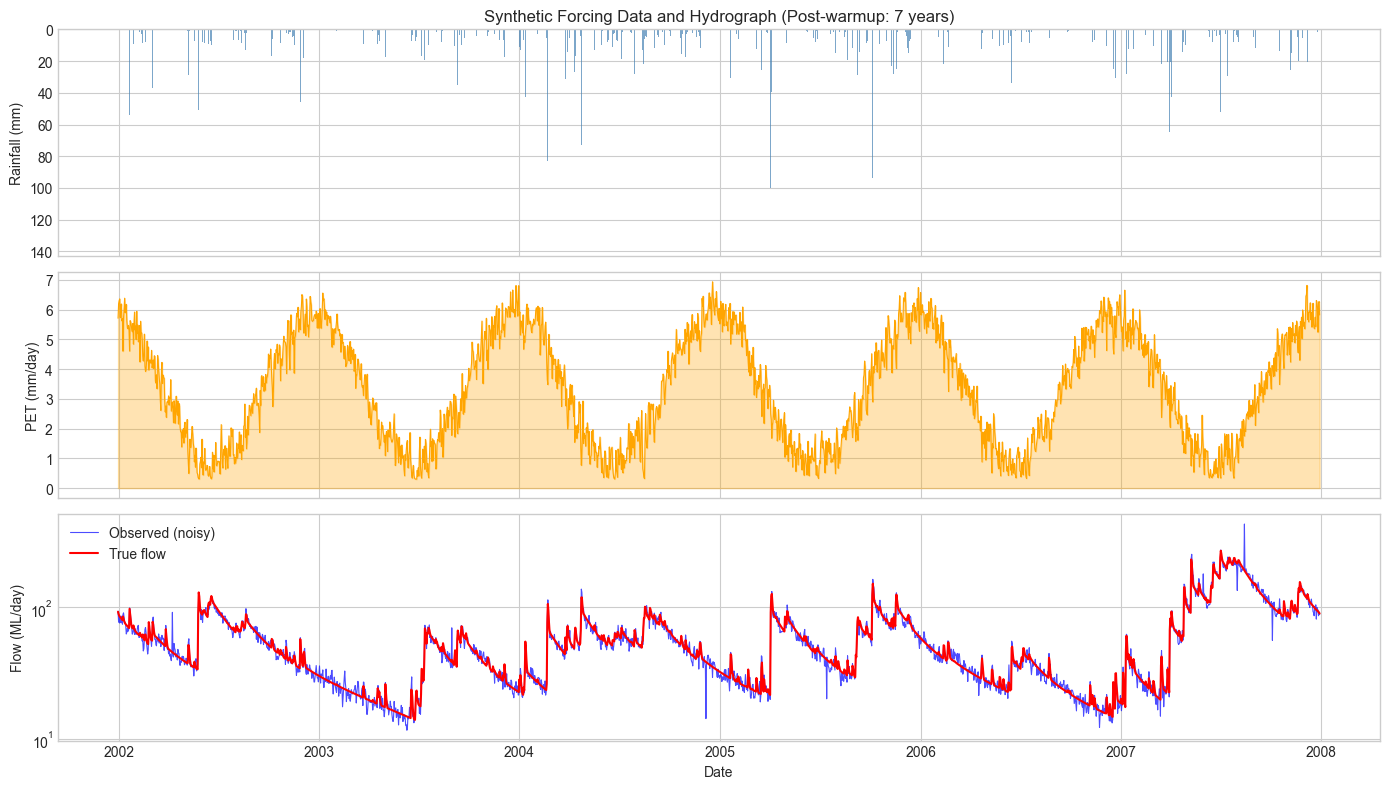


Figure saved: figures/05_synthetic_hydrograph.png
Note: Showing post-warmup period only (7 years)
      First year used as warmup to stabilize model states


In [ ]:
# Run Sacramento model with true parameters to generate synthetic "observed" flow
print("\nRunning Sacramento model with true parameters...")

# Create model with true parameters
SYNTHETIC_CATCHMENT_AREA = 100.0  # km²
true_model = Sacramento(catchment_area_km2=SYNTHETIC_CATCHMENT_AREA)
true_model.set_parameters(TRUE_SAC_PARAMS)
true_model.reset()

# Run model
true_output = true_model.run(synthetic_inputs)
true_flow = true_output['runoff'].values

print(f"  Flow range: {true_flow.min():.1f} - {true_flow.max():.1f} ML/day")
print(f"  Mean flow: {true_flow.mean():.1f} ML/day")

# ============================================================================
# Add realistic observation noise (rating curve uncertainty)
# ============================================================================
# Real streamflow measurements have:
# 1. Heteroscedastic errors (larger absolute errors at high flows)
# 2. Rating curve uncertainty (~5-15% at low flows, ~10-20% at high flows)
# 3. Some temporal autocorrelation in errors
# 4. Occasional measurement outliers

print("\nAdding realistic observation noise...")

# Base noise: proportional to flow magnitude (rating curve uncertainty)
# Higher relative uncertainty at low flows, lower at high flows
relative_error = 0.08 + 0.05 * np.exp(-true_flow / 50)  # 8-13% depending on flow
noise_std = relative_error * true_flow + 0.5  # Plus small constant for very low flows

# Generate noise with some autocorrelation (measurement errors persist slightly)
raw_noise = np.random.normal(0, 1, n_days)
autocorr_noise = np.zeros(n_days)
autocorr_noise[0] = raw_noise[0]
for i in range(1, n_days):
    autocorr_noise[i] = 0.3 * autocorr_noise[i-1] + 0.7 * raw_noise[i]

noise = autocorr_noise * noise_std

# Add occasional outliers (measurement errors, ~1% of days)
outlier_mask = np.random.random(n_days) < 0.01
outlier_magnitude = np.random.choice([-1, 1], n_days) * np.random.exponential(true_flow * 0.3, n_days)
noise[outlier_mask] += outlier_magnitude[outlier_mask]

# Apply noise and ensure positive flow
synthetic_observed = np.maximum(true_flow + noise, 0.1)

# Calculate noise statistics
nse_true_vs_obs = 1 - np.sum((synthetic_observed - true_flow)**2) / np.sum((true_flow - true_flow.mean())**2)
print(f"  Mean true flow: {true_flow.mean():.2f} ML/day")
print(f"  Mean observed (with noise): {synthetic_observed.mean():.2f} ML/day")
print(f"  NSE(true vs observed): {nse_true_vs_obs:.4f}")
print(f"  (This is the 'ceiling' - best achievable NSE due to observation noise)")

# Plot synthetic hydrograph (showing post-warmup period only for calibration view)
# Use 2-year warmup for plotting as well to show clean data
PLOT_WARMUP = 730  # 2 year warmup for visualization

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

# Get post-warmup indices
plot_dates = dates[PLOT_WARMUP:]
plot_rainfall = rainfall[PLOT_WARMUP:]
plot_pet = pet[PLOT_WARMUP:]
plot_observed = synthetic_observed[PLOT_WARMUP:]
plot_true = true_flow[PLOT_WARMUP:]

# Rainfall
ax = axes[0]
ax.bar(plot_dates, plot_rainfall, color='steelblue', alpha=0.7, width=1)
ax.set_ylabel('Rainfall (mm)')
ax.set_title(f'Synthetic Forcing Data and Hydrograph (Post-warmup: {n_years-1} years)')
ax.invert_yaxis()

# PET
ax = axes[1]
ax.plot(plot_dates, plot_pet, color='orange', linewidth=0.8)
ax.set_ylabel('PET (mm/day)')
ax.fill_between(plot_dates, 0, plot_pet, alpha=0.3, color='orange')

# Flow
ax = axes[2]
ax.plot(plot_dates, plot_observed, 'b-', linewidth=0.8, alpha=0.7, label='Observed (noisy)')
ax.plot(plot_dates, plot_true, 'r-', linewidth=1.5, label='True flow')
ax.set_ylabel('Flow (ML/day)')
ax.set_xlabel('Date')
ax.legend()
ax.set_yscale('log')

plt.tight_layout()
plt.savefig(figures_dir / '05_synthetic_hydrograph.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFigure saved: {figures_dir / '05_synthetic_hydrograph.png'}")
print(f"Note: Showing post-warmup period only ({n_years-1} years)")
print(f"      First year used as warmup to stabilize model states")

### Calibration Setup for Synthetic Test

For faster testing, we'll only calibrate a subset of the most sensitive
Sacramento parameters. The full model has 22 parameters, but we'll focus
on the 6 most important ones for this validation.

In [ ]:
# Define subset of parameters to calibrate (for faster testing)
# Includes key baseflow parameters: lzfpm (storage), lzpk (recession rate), pfree (recharge)
CALIBRATION_PARAMS = ['uztwm', 'uzfwm', 'lzfpm', 'uzk', 'lzpk', 'pfree']

# Get parameter bounds for calibration subset
full_bounds = Sacramento().get_parameter_bounds()
subset_bounds = {p: full_bounds[p] for p in CALIBRATION_PARAMS}

print("=" * 70)
print("CALIBRATION SETUP (SYNTHETIC DATA)")
print("=" * 70)
print(f"\nCalibrating {len(CALIBRATION_PARAMS)} parameters (subset for speed):")
for p in CALIBRATION_PARAMS:
    bounds = subset_bounds[p]
    true_val = TRUE_SAC_PARAMS[p]
    print(f"  {p:8s}: bounds [{bounds[0]:>8.3f}, {bounds[1]:>8.3f}], true = {true_val:.3f}")

# Fixed parameters (not calibrated) - these will be set as initial values
fixed_params = {k: v for k, v in TRUE_SAC_PARAMS.items() if k not in CALIBRATION_PARAMS}

# Warmup period - 2 full years to allow groundwater stores to fill
SYNTHETIC_WARMUP = 730  # 2 years warmup for deep groundwater equilibrium

print(f"\nWarmup period: {SYNTHETIC_WARMUP} days (2 years)")
print(f"Calibration period: {n_days - SYNTHETIC_WARMUP} days ({(n_days - SYNTHETIC_WARMUP)/365:.1f} years)")

# Create a CalibrationRunner for synthetic data
# First, set up a model with fixed parameters as starting point
synthetic_model = Sacramento(catchment_area_km2=SYNTHETIC_CATCHMENT_AREA)
synthetic_model.set_parameters(fixed_params)  # Set fixed params as base

# Note: objective and parameter_bounds are passed to CalibrationRunner constructor
# For SCE-UA (optimizer) - use NSE with sqrt transform for BALANCED flow emphasis
# This matches the TransformedGaussianLikelihood('sqrt') used for PyDREAM below
synthetic_runner_sceua = CalibrationRunner(
    model=synthetic_model,
    inputs=synthetic_inputs,
    observed=synthetic_observed,
    objective=NSE(transform=FlowTransformation('sqrt')),  # Balanced: NSE(sqrt)
    parameter_bounds=subset_bounds,  # Only calibrate the subset of parameters
    warmup_period=SYNTHETIC_WARMUP
)

# For PyDREAM (MCMC sampler) - use TransformedGaussianLikelihood (proper log-likelihood)
# This is required because DREAM is a Bayesian MCMC algorithm that samples from the
# posterior distribution and needs a proper log-likelihood, not an efficiency metric.
#
# TransformedGaussianLikelihood implements: log_lik = -n/2 * log(Σ(T(obs) - T(sim))²)
# where T() is a flow transformation function. This formulation (from Vrugt 2016)
# integrates out the measurement error variance.
#
# Flow transformation options:
#   - 'none': High flow emphasis (equivalent to GaussianLikelihood)
#   - 'sqrt': BALANCED emphasis (recommended default) - equivalent to NSE(sqrt)
#   - 'log':  Low flow emphasis - equivalent to LogNSE
#   - 'inverse': Very low flow emphasis - equivalent to InvNSE
#
# Using 'sqrt' for balanced calibration that gives appropriate weight to
# both high flows (peaks) and low flows (baseflow/recession).
synthetic_model_pydream = Sacramento(catchment_area_km2=SYNTHETIC_CATCHMENT_AREA)
synthetic_model_pydream.set_parameters(fixed_params)

synthetic_runner_pydream = CalibrationRunner(
    model=synthetic_model_pydream,
    inputs=synthetic_inputs,
    observed=synthetic_observed,
    objective=TransformedGaussianLikelihood('sqrt'),  # Balanced log-likelihood for MCMC
    parameter_bounds=subset_bounds,
    warmup_period=SYNTHETIC_WARMUP
)

print(f"\nCalibrationRunners created:")
print(f"  - SCE-UA runner: uses NSE(sqrt) (optimizer objective, BALANCED flow emphasis)")
print(f"  - PyDREAM runner: uses TransformedGaussianLikelihood('sqrt') (BALANCED Bayesian log-likelihood)")
print(f"\nBoth algorithms use sqrt transformation for equivalent flow emphasis!")

# Helper function to calculate NSE for any parameter set
# Helper function to calculate NSE(sqrt) for any parameter set - MATCHES the objective used
nse_sqrt_objective = NSE(transform=FlowTransformation('sqrt'))

def calc_synthetic_nse(params_dict):
    """Calculate NSE(sqrt) for a parameter set on synthetic data.
    
    Uses sqrt transformation to match the objective function used by both
    SCE-UA and PyDREAM (TransformedGaussianLikelihood('sqrt')).
    """
    full_params = {**fixed_params, **params_dict}
    model = Sacramento(catchment_area_km2=SYNTHETIC_CATCHMENT_AREA)
    model.set_parameters(full_params)
    model.reset()
    output = model.run(synthetic_inputs)
    simulated = output['runoff'].values[SYNTHETIC_WARMUP:]
    obs = synthetic_observed[SYNTHETIC_WARMUP:]
    
    # Use NSE(sqrt) for balanced flow evaluation
    return nse_sqrt_objective(obs, simulated)

CALIBRATION SETUP (SYNTHETIC DATA)

Calibrating 6 parameters (subset for speed):
  uztwm   : bounds [  25.000,  125.000], true = 50.000
  uzfwm   : bounds [  10.000,   75.000], true = 40.000
  lzfpm   : bounds [  40.000,  600.000], true = 400.000
  uzk     : bounds [   0.200,    0.500], true = 0.250
  lzpk    : bounds [   0.001,    0.015], true = 0.004
  pfree   : bounds [   0.000,    0.500], true = 0.500

Warmup period: 730 days (2 years)
Calibration period: 2190 days (6.0 years)

CalibrationRunners created:
  - SCE-UA runner: uses NSE(sqrt) (optimizer objective, BALANCED flow emphasis)
  - PyDREAM runner: uses TransformedGaussianLikelihood('sqrt') (BALANCED Bayesian log-likelihood)

Both algorithms use sqrt transformation for equivalent flow emphasis!


### Test 1: SCE-UA on Synthetic Hydrograph

In [ ]:
print("=" * 70)
print("TEST 1: SCE-UA ON SYNTHETIC HYDROGRAPH")
print("=" * 70)

# Use CalibrationRunner's run_sceua_direct method
print(f"\nRunning SCE-UA with {len(CALIBRATION_PARAMS)} parameters...")
print("  Max evaluations: 5000")
print("  Using CalibrationRunner.run_sceua_direct()")

start_time = time.time()

sceua_result = synthetic_runner_sceua.run_sceua_direct(
    max_evals=10000,  # Increased for better convergence
    max_tolerant_iter=100,  # Stop after 100 iterations without improvement
    n_complexes=7,  # More complexes for better exploration
    seed=42,
    verbose=True,
    progress_bar=True
)

sceua_time = time.time() - start_time
sceua_params = sceua_result.best_parameters
sceua_nse = sceua_result.best_objective

print(f"\nSCE-UA Results (took {sceua_time:.1f}s):")
print(f"  Best NSE(sqrt): {sceua_nse:.6f}")
print(f"  Function evaluations: {sceua_result.convergence_diagnostics.get('nfev', 'N/A')}")
print(f"\n  {'Parameter':<10} {'True':>10} {'SCE-UA':>10} {'Error':>10}")
print("  " + "-" * 42)
for p in CALIBRATION_PARAMS:
    true_val = TRUE_SAC_PARAMS[p]
    est_val = sceua_params.get(p, true_val)  # Use true if not in calibrated set
    error = abs(est_val - true_val) / true_val * 100
    print(f"  {p:<10} {true_val:>10.3f} {est_val:>10.3f} {error:>9.1f}%")

TEST 1: SCE-UA ON SYNTHETIC HYDROGRAPH

Running SCE-UA with 6 parameters...
  Max evaluations: 5000
  Using CalibrationRunner.run_sceua_direct()
SCE-UA Optimization Started
  Parameters: 6, Complexes: 7, Population: 105
  Max evaluations: 10000, Max iterations: 1000
  Initial best (maximizing): 0.951989
------------------------------------------------------------
  Iter   10: nfev=   175, best=0.970551, no_improve=3
  Iter   20: nfev=   251, best=0.976485, no_improve=9
  Iter   30: nfev=   335, best=0.976485, no_improve=19
  Iter   40: nfev=   456, best=0.976485, no_improve=29
  Iter   50: nfev=   574, best=0.976485, no_improve=39
  Iter   60: nfev=   701, best=0.976485, no_improve=49
  Iter   70: nfev=   835, best=0.976485, no_improve=59
  Iter   80: nfev=   960, best=0.976485, no_improve=69
  Iter   90: nfev=  1074, best=0.976485, no_improve=79
  Iter  100: nfev=  1181, best=0.976485, no_improve=89
  Iter  110: nfev=  1300, best=0.976653, no_improve=2
  Iter  120: nfev=  1414, best=0

### Test 2: PyDREAM on Synthetic Hydrograph

In [ ]:
print("=" * 70)
print("TEST 2: PYDREAM ON SYNTHETIC HYDROGRAPH")
print("=" * 70)

if PYDREAM_AVAILABLE:
    # PyDREAM hyperparameters - MATCHING REAL DATA SETTINGS
    # Same settings used for both synthetic and real data for consistency
    SYNTHETIC_ITERATIONS = 500       # Iterations per chain
    SYNTHETIC_CHAINS = 3             # 3 chains (minimum for DEpairs=1: 2*1+1=3)
    SYNTHETIC_MULTITRY = 1           # Standard DREAM (no multi-try)
    SYNTHETIC_DEPAIRS = 1            # 1 DE pair
    SYNTHETIC_SNOOKER = 0.10         # 10% snooker probability
    SYNTHETIC_CONVERGENCE = 1.05     # Stricter R-hat threshold
    SYNTHETIC_ADAPT_GAMMA = False    # Disabled - PyDREAM NumPy bug
    SYNTHETIC_ADAPT_CROSSOVER = False  # Disabled - PyDREAM NumPy bug
    
    print(f"\nRunning PyDREAM (STANDARD MODE) with {len(CALIBRATION_PARAMS)} parameters...")
    print(f"  Iterations per chain: {SYNTHETIC_ITERATIONS}")
    print(f"  Number of chains: {SYNTHETIC_CHAINS} (parallel)")
    print(f"  Multi-try samples: {SYNTHETIC_MULTITRY}")
    print(f"  DE pairs: {SYNTHETIC_DEPAIRS}")
    print(f"  Snooker probability: {SYNTHETIC_SNOOKER:.0%}")
    print(f"  Adaptive gamma: {SYNTHETIC_ADAPT_GAMMA}")
    print(f"  Adaptive crossover: {SYNTHETIC_ADAPT_CROSSOVER}")
    print(f"  Convergence threshold: GR < {SYNTHETIC_CONVERGENCE}")
    print(f"  Total samples: ~{SYNTHETIC_ITERATIONS * SYNTHETIC_CHAINS:,}")
    
    start_time = time.time()
    
    # Force stdout flush to ensure progress is visible
    import sys
    sys.stdout.flush()
    
    # Ensure figures directory exists (fallback if setup cell wasn't run)
    if 'figures_dir' not in dir():
        figures_dir = Path('figures')
        figures_dir.mkdir(exist_ok=True)
    
    # Use dbname for CSV-based progress tracking - monitor externally with:
    # tail -f figures/pydream_synthetic_progress.csv
    pydream_progress_file = figures_dir / 'pydream_synthetic_progress'
    
    print(f"\n  Progress file: {pydream_progress_file}.csv")
    print(f"  Monitor externally with: tail -f {pydream_progress_file}.csv")
    print("-" * 60)
    sys.stdout.flush()
    
    # Run PyDREAM in STANDARD MODE (no batches, no adaptive features)
    pydream_result = synthetic_runner_pydream.run_pydream(
        n_iterations=SYNTHETIC_ITERATIONS,
        n_chains=SYNTHETIC_CHAINS,
        multitry=SYNTHETIC_MULTITRY,
        snooker=SYNTHETIC_SNOOKER,
        DEpairs=SYNTHETIC_DEPAIRS,
        adapt_crossover=SYNTHETIC_ADAPT_CROSSOVER,  # Disabled - PyDREAM bug
        adapt_gamma=SYNTHETIC_ADAPT_GAMMA,          # Disabled - PyDREAM bug
        convergence_threshold=SYNTHETIC_CONVERGENCE,
        parallel=True,
        dbname=str(pydream_progress_file),
        hardboundaries=True,
        verbose=True,
    )
    
    pydream_time = time.time() - start_time
    
    # Extract results (CalibrationResult is a dataclass, use dot notation)
    pydream_best = pydream_result.best_parameters
    pydream_loglik = pydream_result.best_objective  # This is log-likelihood, not NSE!
    
    # Calculate NSE for the best PyDREAM parameters (for fair comparison with SCE-UA)
    pydream_nse = calc_synthetic_nse(pydream_best)
    
    # Get posterior statistics from all_samples
    all_samples_df = pydream_result.all_samples
    if all_samples_df is not None and len(all_samples_df) > 0:
        # Burn-in: discard first 30%
        burn_in = int(0.3 * len(all_samples_df))
        samples_burned = all_samples_df.iloc[burn_in:]
        
        posterior_means = {p: samples_burned[p].mean() for p in CALIBRATION_PARAMS if p in samples_burned.columns}
        posterior_stds = {p: samples_burned[p].std() for p in CALIBRATION_PARAMS if p in samples_burned.columns}
    else:
        posterior_means = pydream_best.copy()
        posterior_stds = {p: 0.0 for p in CALIBRATION_PARAMS}
    
    # Get convergence diagnostics
    conv_diag = pydream_result.convergence_diagnostics
    converged = conv_diag.get('converged', False) if conv_diag else False
    max_gr = conv_diag.get('max_gr', 'N/A') if conv_diag else 'N/A'
    
    # Check for early stopping info
    early_stopped = pydream_result.early_stopped if hasattr(pydream_result, 'early_stopped') else False
    total_iter = pydream_result.total_iterations if hasattr(pydream_result, 'total_iterations') else SYNTHETIC_ITERATIONS
    
    print(f"\nPyDREAM Results (took {pydream_time:.1f}s):")
    if early_stopped:
        print(f"  ✓ EARLY STOPPED at {total_iter} iterations (max was {SYNTHETIC_ITERATIONS})")
    else:
        print(f"  Total iterations: {total_iter} per chain")
    if converged:
        print(f"  ✓ CONVERGED (max GR: {max_gr:.4f} < {SYNTHETIC_CONVERGENCE})")
    else:
        print(f"  ○ Not converged (max GR: {max_gr if isinstance(max_gr, str) else f'{max_gr:.4f}'} >= {SYNTHETIC_CONVERGENCE})")
    print(f"  Best log-likelihood: {pydream_loglik:.4f}")
    print(f"  Best NSE(sqrt) (calculated): {pydream_nse:.6f}")
    print(f"\n  {'Parameter':<10} {'True':>10} {'MAP':>10} {'Mean±Std':>20}")
    print("  " + "-" * 52)
    for p in CALIBRATION_PARAMS:
        true_val = TRUE_SAC_PARAMS[p]
        map_val = pydream_best.get(p, true_val)
        mean_val = posterior_means.get(p, map_val)
        std_val = posterior_stds.get(p, 0.0)
        print(f"  {p:<10} {true_val:>10.3f} {map_val:>10.3f} {mean_val:>10.3f}±{std_val:<8.3f}")
    
else:
    print("\n⚠ PyDREAM not available - skipping test")
    pydream_best = None
    posterior_means = None
    posterior_stds = None
    pydream_time = 0
    pydream_nse = np.nan

TEST 2: PYDREAM ON SYNTHETIC HYDROGRAPH

Running PyDREAM (STANDARD MODE) with 6 parameters...
  Iterations per chain: 500
  Number of chains: 3 (parallel)
  Multi-try samples: 1
  DE pairs: 1
  Snooker probability: 10%
  Adaptive gamma: False
  Adaptive crossover: False
  Convergence threshold: GR < 1.05
  Total samples: ~1,500

  Progress file: figures/pydream_synthetic_progress.csv
  Monitor externally with: tail -f figures/pydream_synthetic_progress.csv
------------------------------------------------------------
  - Progress tracking: figures/pydream_synthetic_progress.csv
Running PyDREAM (MT-DREAM(ZS)) - NORMAL MODE
  - 500 iterations per chain
  - 3 chains (running in parallel)
  - 1 multi-try samples (parallel)
  - 10.0% snooker probability
  - 1 DE pairs
  - 6 parameters
  - Multi-try parallelization: ENABLED
  - Convergence check: ENABLED (GR threshold: 1.05)
Iteration:  0  acceptance rate:  0.0
Iteration:  0  acceptance rate over last 100 iterations:  0.0
Iteration:  0  accep

/opt/homebrew/Caskroom/miniforge/base/envs/pyrrm/lib/python3.11/site-packages/pydream/Dream.py:323: RuntimeWarning: divide by zero encountered in log
  q_new = metrop_select(np.nan_to_num(np.log(np.sum(weight_proposed)/np.sum(weight_reference))), q_proposal, q0)


Did not accept point.  Kept old logp:  -9613.530411026253  Tested logp:  -9298.122852044346  weight proposed:  [-9298.12285204 -9595.91198799 -9421.72605839 -9583.96928995
 -9613.53041103]  weight ref:  [-8906.70701277 -9839.14155257 -9829.90997561 -9619.42754996
 -9613.53041103]  ratio:  1.0239078519474457e-170  at temperature:  1.0
Did not accept point.  Kept old logp:  -8609.10763873716  Tested logp:  -9408.027480814711  weight proposed:  [ -9418.97497951 -10127.88288763  -9491.33220658  -9408.02748081
  -9982.97016542]  weight ref:  [-8594.77320811 -9875.71410469 -9869.50601366 -9464.57206313
 -8609.10763874]  ratio:  0.0  at temperature:  1.0
Did not accept point.  Kept old logp:  -8370.140772968853  Tested logp:  -8099.868053879856  weight proposed:  [ -8471.34262065  -8380.95284763  -8099.86805388  -9380.3579175
 -10014.64150844]  weight ref:  [-8640.22023133 -9293.2129827  -9405.76276752 -7239.73897025
 -8370.14077297]  ratio:  0.0  at temperature:  1.0


/opt/homebrew/Caskroom/miniforge/base/envs/pyrrm/lib/python3.11/site-packages/pydream/Dream.py:323: RuntimeWarning: divide by zero encountered in log
  q_new = metrop_select(np.nan_to_num(np.log(np.sum(weight_proposed)/np.sum(weight_reference))), q_proposal, q0)
/opt/homebrew/Caskroom/miniforge/base/envs/pyrrm/lib/python3.11/site-packages/pydream/Dream.py:323: RuntimeWarning: divide by zero encountered in log
  q_new = metrop_select(np.nan_to_num(np.log(np.sum(weight_proposed)/np.sum(weight_reference))), q_proposal, q0)


Accepted point.  New logp:  -7157.131455120744  old logp:  -8609.10763873716  weight proposed:  [ -9141.96315928  -9326.42218828 -10182.41939019  -7940.28525066
  -7157.13145512]  weight ref:  [-9134.50176687 -9562.14184779 -7507.47162211 -9403.70105038
 -8609.10763874]  ratio:  1.4151462114630876e+152  at temperature:  1.0
Did not accept point.  Kept old logp:  -9613.530411026253  Tested logp:  -9162.93582293532  weight proposed:  [ -9361.17552433  -9389.34819489  -9162.93582294 -10675.29571206
  -9613.37347134]  weight ref:  [-9409.08995164 -9162.93582294 -9654.06460976 -8861.37372697
 -9613.53041103]  ratio:  1.0795574799052353e-131  at temperature:  1.0
Did not accept point.  Kept old logp:  -8370.140772968853  Tested logp:  -8777.890299516912  weight proposed:  [-8777.89029952 -8893.39775527 -9825.10745979 -8924.76248149
 -8864.12070559]  weight ref:  [-8732.81261597 -9611.65743557 -9023.92595925 -9754.59665015
 -8370.14077297]  ratio:  8.253356820146087e-178  at temperature:  1.0

...

Did not accept point.  Kept old logp:  -6118.153080387567  Tested logp:  -6118.153080387567  weight proposed:  [-6118.15308039 -6976.86218473 -6181.80549677 -7353.60903394
 -8179.84951856]  weight ref:  [-10529.75149176  -6568.48260341  -7702.9689282  -10963.99456564
  -6118.15308039]  ratio:  inf  at temperature:  1.0
Accepted point.  New logp:  -6116.320687357208  old logp:  -6116.003661379443  weight proposed:  [-9342.81278938 -6182.86113411 -7128.38235699 -6494.99895952
 -6116.32068736]  weight ref:  [-8556.57893894 -6643.90103661 -6135.71518844 -7983.56982196
 -6116.00366138]  ratio:  0.7283118329629052  at temperature:  1.0
Did not accept point.  Kept old logp:  -6117.255407299373  Tested logp:  -6119.237903374025  weight proposed:  [ -6123.60744137  -6119.23790337 -10452.33707259  -8913.11769501
  -7917.3274272 ]  weight ref:  [-10109.50973936  -6483.4973056   -7398.5398754   -9522.50481109
  -6117.2554073 ]  ratio:  0.03439388058804433  at temperature:  1.0
Accepted point.  New

/opt/homebrew/Caskroom/miniforge/base/envs/pyrrm/lib/python3.11/site-packages/pydream/Dream.py:820: RuntimeWarning: invalid value encountered in scalar divide
  zP = np.nan_to_num(np.array([(np.sum(diff_chains_to_be_projected[point]*proj_vec_diff[point])/D[point] *proj_vec_diff[point]) for point in range(n_proposed_pts)]))


Accepted point.  New logp:  -6120.387663188586  old logp:  -6120.766707049865  weight proposed:  [-6137.46298573 -6120.38766319 -7397.51300105 -6124.79023841
 -7832.39154813]  weight ref:  [-10609.46809931  -7820.33485414  -6899.47863639  -7597.17976549
  -6120.76670705]  ratio:  1.478776845160977  at temperature:  1.0
Did not accept point.  Kept old logp:  -6116.3206873572635  Tested logp:  -6205.739166111731  weight proposed:  [-7050.75525127 -6205.73916611 -7611.55162224 -7967.20791555
 -7271.27815088]  weight ref:  [-8218.37834449 -6170.64604565 -7150.02972084 -6206.31128468
 -6116.32068736]  ratio:  1.4657101547702885e-39  at temperature:  1.0


/opt/homebrew/Caskroom/miniforge/base/envs/pyrrm/lib/python3.11/site-packages/pydream/Dream.py:323: RuntimeWarning: divide by zero encountered in scalar divide
  q_new = metrop_select(np.nan_to_num(np.log(np.sum(weight_proposed)/np.sum(weight_reference))), q_proposal, q0)
/opt/homebrew/Caskroom/miniforge/base/envs/pyrrm/lib/python3.11/site-packages/pydream/Dream.py:356: RuntimeWarning: divide by zero encountered in scalar divide
  print('Did not accept point.  Kept old logp: ',self.last_logp,' Tested logp: ',q_logp,' weight proposed: ',log_ps,' weight ref: ',ref_log_ps,' ratio: ',np.sum(weight_proposed)/np.sum(weight_reference),' at temperature: ',T)


Did not accept point.  Kept old logp:  -6117.255407299373  Tested logp:  -6117.255407299373  weight proposed:  [ -6117.2554073   -9494.71790619  -8822.94362165 -10011.71305018
  -8386.03383745]  weight ref:  [-8009.52074882 -6459.86355322 -6122.43221532 -7789.69589204
 -6117.2554073 ]  ratio:  inf  at temperature:  1.0
Did not accept point.  Kept old logp:  -6120.387663188586  Tested logp:  -6121.97760894556  weight proposed:  [-8221.31434875 -6838.6402043  -6121.97760895 -8340.65290982
 -6228.12965261]  weight ref:  [-6784.58984012 -8093.09495906 -6144.65293555 -6214.40856252
 -6120.38766319]  ratio:  0.20393667357058404  at temperature:  1.0
Did not accept point.  Kept old logp:  -6116.3206873572635  Tested logp:  -6119.852302683531  weight proposed:  [-6119.85230268 -6435.03764734 -6171.56893161 -6327.86682831
 -6913.13672058]  weight ref:  [-6760.73213293 -6120.74637606 -6168.78617801 -6171.68118001
 -6116.32068736]  ratio:  0.028911661084138267  at temperature:  1.0
Did not accept

### Comparison: SCE-UA vs PyDREAM on Synthetic Hydrograph

COMPARISON: SCE-UA vs PyDREAM (SYNTHETIC HYDROGRAPH)


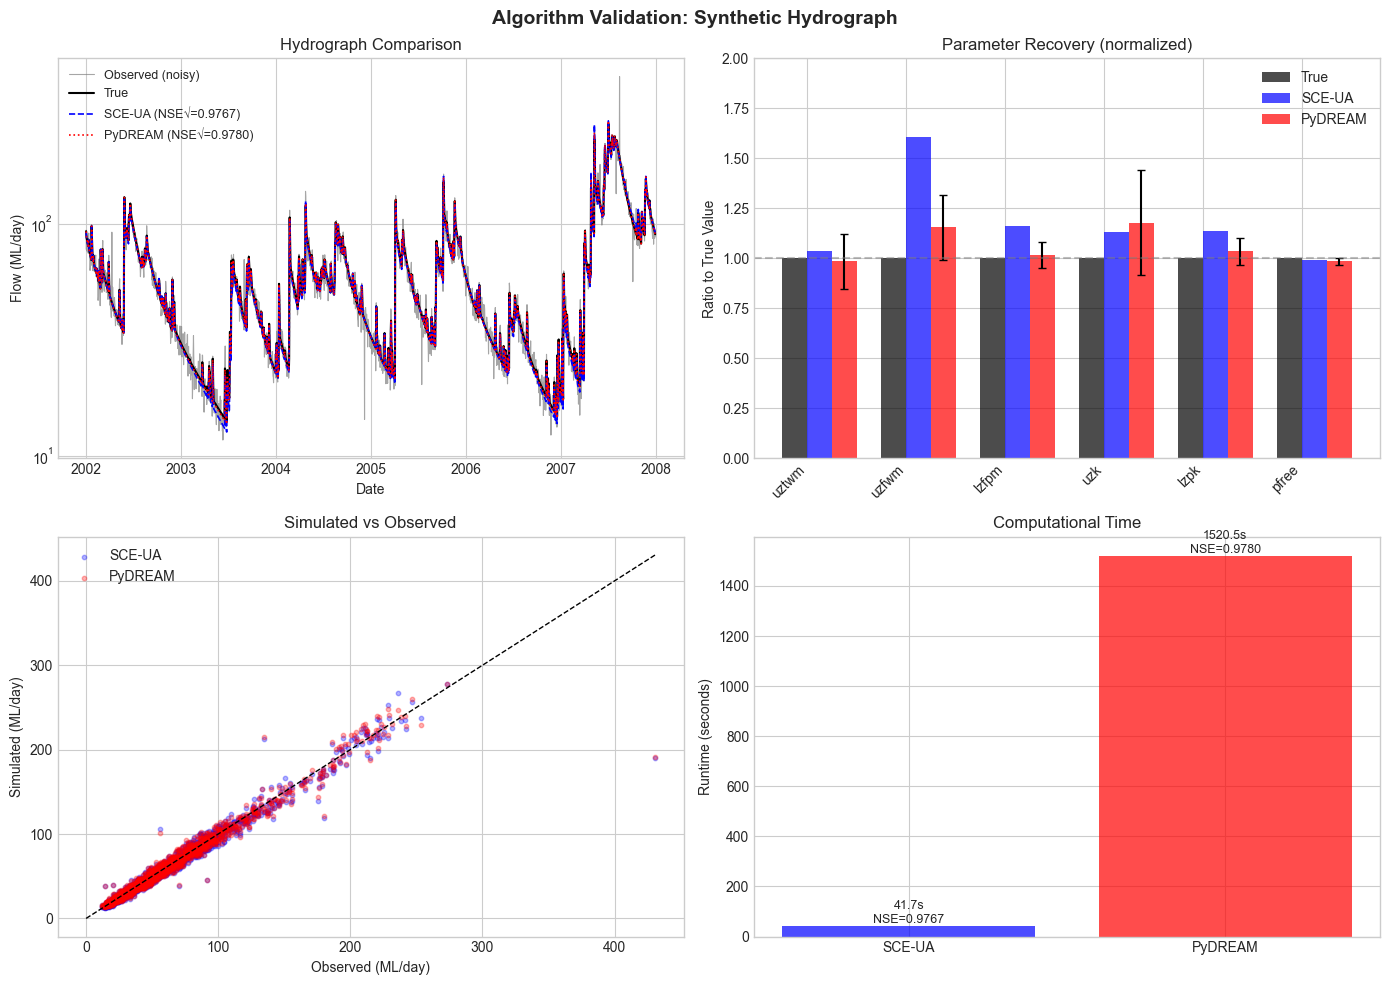


VALIDATION SUMMARY

Both algorithms optimized NSE(sqrt) for balanced flow emphasis

Metric                             SCE-UA         PyDREAM
-------------------------------------------------------
NSE(sqrt)                          0.9767          0.9780
Runtime (seconds)                    41.7          1520.5

SCE-UA validation:        ✓ PASSED
PyDREAM validation:       ✓ PASSED

✓ Both algorithms successfully validated!
  Ready to proceed with real data calibrations.

Figure saved: figures/05_synthetic_validation.png


In [ ]:
print("=" * 70)
print("COMPARISON: SCE-UA vs PyDREAM (SYNTHETIC HYDROGRAPH)")
print("=" * 70)

# Run both calibrated models
sceua_full_params = {**fixed_params, **sceua_params}
sceua_model = Sacramento(catchment_area_km2=SYNTHETIC_CATCHMENT_AREA)
sceua_model.set_parameters(sceua_full_params)
sceua_model.reset()
sceua_sim = sceua_model.run(synthetic_inputs)['runoff'].values

if PYDREAM_AVAILABLE and pydream_best is not None:
    pydream_full_params = {**fixed_params, **pydream_best}
    pydream_model = Sacramento(catchment_area_km2=SYNTHETIC_CATCHMENT_AREA)
    pydream_model.set_parameters(pydream_full_params)
    pydream_model.reset()
    pydream_sim = pydream_model.run(synthetic_inputs)['runoff'].values
else:
    pydream_sim = None

# Create comparison figure
fig = plt.figure(figsize=(14, 10))

# 1. Hydrograph comparison
ax1 = plt.subplot(2, 2, 1)
ax1.plot(dates[SYNTHETIC_WARMUP:], synthetic_observed[SYNTHETIC_WARMUP:], 
         'gray', alpha=0.7, linewidth=0.8, label='Observed (noisy)')
ax1.plot(dates[SYNTHETIC_WARMUP:], true_flow[SYNTHETIC_WARMUP:], 
         'k-', linewidth=1.5, label='True')
ax1.plot(dates[SYNTHETIC_WARMUP:], sceua_sim[SYNTHETIC_WARMUP:], 
         'b--', linewidth=1.2, label=f'SCE-UA (NSE√={sceua_nse:.4f})')
if pydream_sim is not None:
    ax1.plot(dates[SYNTHETIC_WARMUP:], pydream_sim[SYNTHETIC_WARMUP:], 
             'r:', linewidth=1.2, label=f'PyDREAM (NSE√={pydream_nse:.4f})')
ax1.set_ylabel('Flow (ML/day)')
ax1.set_xlabel('Date')
ax1.set_title('Hydrograph Comparison')
ax1.legend(fontsize=9)
ax1.set_yscale('log')

# 2. Parameter recovery
ax2 = plt.subplot(2, 2, 2)
x_pos = np.arange(len(CALIBRATION_PARAMS))
width = 0.25

true_vals = [TRUE_SAC_PARAMS[p] for p in CALIBRATION_PARAMS]
sceua_vals = [sceua_params.get(p, TRUE_SAC_PARAMS[p]) for p in CALIBRATION_PARAMS]

# Normalize by true values for comparison
true_norm = [1.0] * len(CALIBRATION_PARAMS)
sceua_norm = [sceua_params.get(p, TRUE_SAC_PARAMS[p]) / TRUE_SAC_PARAMS[p] for p in CALIBRATION_PARAMS]

ax2.bar(x_pos - width/2, true_norm, width, label='True', color='black', alpha=0.7)
ax2.bar(x_pos + width/2, sceua_norm, width, label='SCE-UA', color='blue', alpha=0.7)

if PYDREAM_AVAILABLE and posterior_means is not None:
    pydream_norm = [posterior_means.get(p, TRUE_SAC_PARAMS[p]) / TRUE_SAC_PARAMS[p] for p in CALIBRATION_PARAMS]
    pydream_err = [posterior_stds.get(p, 0.0) / TRUE_SAC_PARAMS[p] for p in CALIBRATION_PARAMS]
    ax2.bar(x_pos + width*1.5, pydream_norm, width, label='PyDREAM', color='red', alpha=0.7,
            yerr=pydream_err, capsize=3)

ax2.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(CALIBRATION_PARAMS, rotation=45, ha='right')
ax2.set_ylabel('Ratio to True Value')
ax2.set_title('Parameter Recovery (normalized)')
ax2.legend()
ax2.set_ylim(0, 2)

# 3. Scatter plot
ax3 = plt.subplot(2, 2, 3)
obs_compare = synthetic_observed[SYNTHETIC_WARMUP:]
ax3.scatter(obs_compare, sceua_sim[SYNTHETIC_WARMUP:], alpha=0.3, s=10, 
            color='blue', label='SCE-UA')
if pydream_sim is not None:
    ax3.scatter(obs_compare, pydream_sim[SYNTHETIC_WARMUP:], alpha=0.3, s=10, 
                color='red', label='PyDREAM')
max_val = max(obs_compare.max(), sceua_sim[SYNTHETIC_WARMUP:].max())
ax3.plot([0, max_val], [0, max_val], 'k--', linewidth=1)
ax3.set_xlabel('Observed (ML/day)')
ax3.set_ylabel('Simulated (ML/day)')
ax3.set_title('Simulated vs Observed')
ax3.legend()

# 4. Runtime comparison
ax4 = plt.subplot(2, 2, 4)
methods = ['SCE-UA']
times = [sceua_time]
nses = [sceua_nse]
colors = ['blue']

if PYDREAM_AVAILABLE and pydream_time > 0:
    methods.append('PyDREAM')
    times.append(pydream_time)
    nses.append(pydream_nse)
    colors.append('red')

bars = ax4.bar(methods, times, color=colors, alpha=0.7)
ax4.set_ylabel('Runtime (seconds)')
ax4.set_title('Computational Time')
for i, (bar, t, nse) in enumerate(zip(bars, times, nses)):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{t:.1f}s\nNSE={nse:.4f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Algorithm Validation: Synthetic Hydrograph', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(figures_dir / '05_synthetic_validation.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary
print("\n" + "=" * 70)
print("VALIDATION SUMMARY")
print("=" * 70)
print("\nBoth algorithms optimized NSE(sqrt) for balanced flow emphasis")
print(f"\n{'Metric':<25} {'SCE-UA':>15} {'PyDREAM':>15}")
print("-" * 55)
print(f"{'NSE(sqrt)':<25} {sceua_nse:>15.4f} {pydream_nse:>15.4f}")
print(f"{'Runtime (seconds)':<25} {sceua_time:>15.1f} {pydream_time:>15.1f}")

# Check if both algorithms recovered reasonable parameters
sceua_ok = sceua_nse > 0.9
pydream_ok = pydream_nse > 0.9 if PYDREAM_AVAILABLE else True

print(f"\n{'SCE-UA validation:':<25} {'✓ PASSED' if sceua_ok else '✗ FAILED'}")
print(f"{'PyDREAM validation:':<25} {'✓ PASSED' if pydream_ok else '✗ FAILED'}")

if sceua_ok and pydream_ok:
    print("\n✓ Both algorithms successfully validated!")
    print("  Ready to proceed with real data calibrations.")
else:
    print("\n⚠ Validation issues detected - review results before proceeding.")

print(f"\nFigure saved: {figures_dir / '05_synthetic_validation.png'}")

---
## Run PyDREAM Calibrations (Real Data)

Now that we've validated both algorithms work correctly, we run PyDREAM
for all 13 objective functions on the real hydrological data.

**Note**: Results are saved to disk, so subsequent runs can skip calibration.

In [ ]:
# Directory for PyDREAM results
PYDREAM_RESULTS_DIR = REPORTS_DIR / 'pydream'
PYDREAM_RESULTS_DIR.mkdir(exist_ok=True)

# Storage for PyDREAM results
pydream_results = {}
pydream_reports = {}

print(f"PyDREAM results directory: {PYDREAM_RESULTS_DIR}")

PyDREAM results directory: ../test_data/reports/pydream


In [ ]:
# =============================================================================
# GELMAN-RUBIN R-HAT IMPLEMENTATION
# =============================================================================
# Same implementation as Notebook 08 (Calibration Monitor) for consistency.
# Uses PyDREAM's Gelman_Rubin function when available, with proper chain handling.

try:
    from pydream.convergence import Gelman_Rubin as pydream_gelman_rubin
    PYDREAM_GR_AVAILABLE = True
except ImportError:
    PYDREAM_GR_AVAILABLE = False

# Minimum samples per chain for reliable R-hat (after 50% burn-in removal)
MIN_SAMPLES_PER_CHAIN_RELIABLE = 100
MIN_SAMPLES_PER_CHAIN_MARGINAL = 50
MIN_SAMPLES_PER_CHAIN_MINIMUM = 20


def _compute_gelman_rubin_fallback(chains: list, param_names: list) -> dict:
    """
    Fallback Gelman-Rubin implementation matching PyDREAM's formula.
    
    Uses 50% burn-in removal and standard Gelman-Rubin formula.
    Reference: Gelman & Rubin (1992). Statistical Science, 7(4), 457-472.
    """
    nchains = len(chains)
    nsamples = len(chains[0])
    nburnin = nsamples // 2
    
    r_hat_values = {}
    
    for i, param in enumerate(param_names):
        # Extract parameter values for all chains, after burn-in
        param_chains = [chain[nburnin:, i] for chain in chains]
        
        # Within-chain variance
        chain_vars = [np.var(c, ddof=1) for c in param_chains]
        W = np.mean(chain_vars)
        
        # Between-chain variance
        chain_means = [np.mean(c) for c in param_chains]
        B = np.var(chain_means, ddof=1)
        
        # Variance estimate
        n_post_burnin = nsamples - nburnin
        var_est = W * (1 - 1./n_post_burnin) + B
        
        # R-hat
        if W > 1e-10:
            r_hat = np.sqrt(var_est / W)
        else:
            r_hat = np.nan
        
        r_hat_values[param] = r_hat
    
    return r_hat_values


def compute_gelman_rubin_from_progress(progress_file: Path, param_names: list, n_chains: int = 3) -> dict:
    """
    Compute Gelman-Rubin R-hat from PyDREAM progress CSV file.
    
    Same implementation as Notebook 08 for consistency.
    
    Args:
        progress_file: Path to progress CSV (without .csv extension)
        param_names: List of parameter names
        n_chains: Number of chains (default 3)
        
    Returns:
        Dictionary with r_hat values, reliability info, etc.
    """
    csv_path = Path(str(progress_file) + '.csv')
    
    if not csv_path.exists():
        return {'r_hat': {p: np.nan for p in param_names}, 'reliability': 'no_file'}
    
    try:
        df = pd.read_csv(csv_path)
    except Exception as e:
        return {'r_hat': {p: np.nan for p in param_names}, 'reliability': 'read_error', 'error': str(e)}
    
    # Check for chain column (PyDREAM adapter adds this)
    if 'chain' in df.columns:
        chain_groups = df.groupby('chain')
        n_chains = len(chain_groups)
        chains = []
        for chain_id in sorted(df['chain'].unique()):
            chain_df = df[df['chain'] == chain_id]
            chain_data = chain_df[param_names].values
            chains.append(chain_data)
        min_len = min(len(c) for c in chains)
        chains = [c[:min_len] for c in chains]
        samples_per_chain = min_len
    else:
        # Interleaved format
        values = df[param_names].values
        n_total = len(values)
        samples_per_chain = n_total // n_chains
        chains = []
        for chain_idx in range(n_chains):
            chain_data = values[chain_idx::n_chains][:samples_per_chain]
            chains.append(chain_data)
    
    # PyDREAM uses 50% burn-in
    effective_samples = samples_per_chain // 2
    
    # Determine reliability
    if effective_samples < MIN_SAMPLES_PER_CHAIN_MINIMUM:
        reliability = 'insufficient'
    elif effective_samples < MIN_SAMPLES_PER_CHAIN_MARGINAL:
        reliability = 'unreliable'
    elif effective_samples < MIN_SAMPLES_PER_CHAIN_RELIABLE:
        reliability = 'marginal'
    else:
        reliability = 'reliable'
    
    # Compute R-hat
    r_hat_values = {}
    method = 'unknown'
    
    if PYDREAM_GR_AVAILABLE and reliability != 'insufficient':
        try:
            gr_array = pydream_gelman_rubin(chains)
            for i, param in enumerate(param_names):
                r_hat_values[param] = float(gr_array[i])
            method = 'pydream'
        except Exception as e:
            method = 'fallback'
            r_hat_values = _compute_gelman_rubin_fallback(chains, param_names)
    elif reliability == 'insufficient':
        for param in param_names:
            r_hat_values[param] = np.nan
        method = 'insufficient_samples'
    else:
        method = 'fallback'
        r_hat_values = _compute_gelman_rubin_fallback(chains, param_names)
    
    return {
        'r_hat': r_hat_values,
        'n_chains': n_chains,
        'samples_per_chain': samples_per_chain,
        'effective_samples': effective_samples,
        'reliability': reliability,
        'method': method
    }


def print_rhat_summary(gr_result: dict, threshold: float = 1.05):
    """Print R-hat summary with interpretation."""
    r_hat = gr_result['r_hat']
    reliability = gr_result.get('reliability', 'unknown')
    method = gr_result.get('method', 'unknown')
    
    if reliability in ['no_file', 'read_error']:
        print(f"  R-hat: Cannot compute ({reliability})")
        return False
    
    if reliability == 'insufficient':
        effective = gr_result.get('effective_samples', 0)
        print(f"  R-hat: Insufficient samples ({effective} < {MIN_SAMPLES_PER_CHAIN_MINIMUM})")
        return False
    
    # Compute summary statistics
    valid_rhats = [v for v in r_hat.values() if not np.isnan(v)]
    if not valid_rhats:
        print(f"  R-hat: No valid values")
        return False
    
    max_rhat = max(valid_rhats)
    n_converged = sum(1 for v in valid_rhats if v < threshold)
    n_total = len(valid_rhats)
    
    # Determine status
    if max_rhat < 1.01:
        status = "✓✓ Excellent"
    elif max_rhat < 1.05:
        status = "✓ Good"
    elif max_rhat < 1.1:
        status = "~ Acceptable"
    elif max_rhat < 1.2:
        status = "⚠ Borderline"
    else:
        status = "✗ Not converged"
    
    print(f"  R-hat ({method}): max={max_rhat:.3f} {status}")
    print(f"  Converged: {n_converged}/{n_total} parameters (R-hat < {threshold})")
    
    if reliability == 'marginal':
        print(f"  ⚠ Marginal sample size - R-hat estimates may be noisy")
    
    return max_rhat < threshold

In [ ]:
# Helper function to run a single PyDREAM calibration
def run_pydream_calibration(obj_name, objective_func):
    """
    Run PyDREAM calibration for a single objective function.
    
    Returns the result and report, or loads from disk if already exists.
    """
    result_file = PYDREAM_RESULTS_DIR / f'410734_pydream_{obj_name.lower()}.pkl'
    progress_file = PYDREAM_RESULTS_DIR / f'progress_{obj_name.lower()}'
    
    print("=" * 60)
    print(f"PyDREAM CALIBRATION: {obj_name}")
    print("=" * 60)
    
    # Check if already exists
    if result_file.exists():
        print(f"Loading existing result: {result_file.name}")
        report = CalibrationReport.load(str(result_file))
        result = report.result
        print(f"✓ Loaded (Best objective: {result.best_objective:.4f})")
        if hasattr(result, 'actual_objective_value'):
            print(f"  Actual {obj_name}: {result.actual_objective_value:.4f}")
        
        # Compute R-hat from progress file if it exists
        param_names = list(result.best_parameters.keys())
        gr_result = compute_gelman_rubin_from_progress(progress_file, param_names, PYDREAM_CHAINS)
        print_rhat_summary(gr_result, PYDREAM_CONVERGENCE_THRESHOLD)
        
        return result, report
    
    if not PYDREAM_AVAILABLE:
        print("✗ PyDREAM not available!")
        return None, None
    
    # Get likelihood transform
    likelihood_transform = LIKELIHOOD_TRANSFORM_MAPPING.get(obj_name, 'sqrt')
    likelihood = TransformedGaussianLikelihood(likelihood_transform)
    
    print(f"Objective: {obj_name}")
    print(f"Likelihood: TransformedGaussianLikelihood('{likelihood_transform}')")
    print(f"Flow emphasis: {likelihood.flow_emphasis}")
    print(f"Config: {PYDREAM_ITERATIONS} iter × {PYDREAM_CHAINS} chains")
    print(f"Monitor: tail -f {progress_file}.csv")
    print("-" * 60)
    
    # Create runner
    runner = CalibrationRunner(
        model=Sacramento(catchment_area_km2=CATCHMENT_AREA_KM2),
        inputs=cal_inputs,
        observed=cal_observed,
        objective=likelihood,
        warmup_period=WARMUP_DAYS
    )
    
    start_time = time.time()
    
    try:
        result = runner.run_pydream(
            n_iterations=PYDREAM_ITERATIONS,
            n_chains=PYDREAM_CHAINS,
            multitry=PYDREAM_MULTITRY,
            snooker=PYDREAM_SNOOKER,
            DEpairs=PYDREAM_DEPAIRS,
            parallel=True,
            adapt_crossover=PYDREAM_ADAPT_CROSSOVER,
            adapt_gamma=PYDREAM_ADAPT_GAMMA,
            verbose=True,
            nverbose=100,
            dbname=str(progress_file),
            hardboundaries=True,
            convergence_check=True,
            convergence_threshold=PYDREAM_CONVERGENCE_THRESHOLD
        )
        
        elapsed = time.time() - start_time
        print("-" * 60)
        print(f"✓ Completed in {elapsed:.1f}s")
        print(f"Best log-likelihood: {result.best_objective:.4f}")
        
        # Calculate actual objective value
        eval_model = Sacramento(catchment_area_km2=CATCHMENT_AREA_KM2)
        eval_model.set_parameters(result.best_parameters)
        eval_model.reset()
        sim_output = eval_model.run(cal_inputs)
        sim_values = sim_output['runoff'].values[WARMUP_DAYS:]
        obs_values = cal_observed[WARMUP_DAYS:]
        
        actual_obj_value = objective_func(obs_values, sim_values)
        print(f"Actual {obj_name}: {actual_obj_value:.4f}")
        
        result.actual_objective_value = actual_obj_value
        result.objective_name = obj_name
        
        # Compute R-hat using same implementation as Notebook 08
        param_names = list(result.best_parameters.keys())
        gr_result = compute_gelman_rubin_from_progress(progress_file, param_names, PYDREAM_CHAINS)
        print_rhat_summary(gr_result, PYDREAM_CONVERGENCE_THRESHOLD)
        
        # Store R-hat in result for later analysis
        result.gelman_rubin_results = gr_result
        
        # Save
        report = runner.create_report(result, catchment_info={
            'name': 'Queanbeyan River', 
            'gauge_id': '410734', 
            'area_km2': CATCHMENT_AREA_KM2
        })
        report.save(str(result_file.with_suffix('')))
        print(f"✓ Saved to: {result_file}")
        
        return result, report
        
    except Exception as e:
        print(f"✗ Failed: {e}")
        import traceback
        traceback.print_exc()
        return None, None

### Calibration 1/13: NSE (High-flow emphasis)

In [ ]:
result, report = run_pydream_calibration('NSE', objectives['NSE'])
if result: pydream_results['NSE'] = result; pydream_reports['NSE'] = report

PyDREAM CALIBRATION: NSE
Objective: NSE
Likelihood: TransformedGaussianLikelihood('none')
Flow emphasis: high
Config: 500 iter × 3 chains
Monitor: tail -f ../test_data/reports/pydream/progress_nse.csv
------------------------------------------------------------
  - Progress tracking: ../test_data/reports/pydream/progress_nse.csv
Running PyDREAM (MT-DREAM(ZS)) - NORMAL MODE
  - 500 iterations per chain
  - 3 chains (running in parallel)
  - 1 multi-try samples (parallel)
  - 10.0% snooker probability
  - 1 DE pairs
  - 22 parameters
  - Multi-try parallelization: ENABLED
  - Convergence check: ENABLED (GR threshold: 1.05)
Iteration:  0  acceptance rate:  0.0
Iteration:  0  acceptance rate over last 100 iterations:  0.0
History file not loaded.
Seeding history with  220  draws from prior.
Iteration:  0  acceptance rate:  0.0
Iteration:  0  acceptance rate over last 100 iterations:  0.0
Setting crossover probability starting values.
Set probability of different crossover values to:  [0.33

/opt/homebrew/Caskroom/miniforge/base/envs/pyrrm/lib/python3.11/site-packages/pydream/Dream.py:323: RuntimeWarning: divide by zero encountered in log
  q_new = metrop_select(np.nan_to_num(np.log(np.sum(weight_proposed)/np.sum(weight_reference))), q_proposal, q0)
/opt/homebrew/Caskroom/miniforge/base/envs/pyrrm/lib/python3.11/site-packages/pydream/Dream.py:323: RuntimeWarning: divide by zero encountered in log
  q_new = metrop_select(np.nan_to_num(np.log(np.sum(weight_proposed)/np.sum(weight_reference))), q_proposal, q0)


Did not accept point.  Kept old logp:  -144475.0962613625  Tested logp:  -142618.30702728615  weight proposed:  [-143961.33081117 -143445.55862659 -145762.62471339 -144865.33864968
 -142618.30702729]  weight ref:  [-143218.78336899 -142941.69359306 -144612.67669302 -140277.40086308
 -144475.09626136]  ratio:  0.0  at temperature:  1.0
Did not accept point.  Kept old logp:  -140867.32323015362  Tested logp:  -138635.6360988396  weight proposed:  [-141451.14405521 -141335.71273431 -142846.07247809 -138635.63609884
 -142844.77596696]  weight ref:  [-137729.40725588 -137968.79204461 -141690.0064343  -138675.65355146
 -140867.32323015]  ratio:  0.0  at temperature:  1.0
Did not accept point.  Kept old logp:  -147045.37400357486  Tested logp:  -136516.30985720977  weight proposed:  [-144049.83540435 -147994.60387833 -146839.26104238 -136516.30985721
 -144556.46046056]  weight ref:  [-138852.51810858 -138532.54704956 -136536.54225478 -139102.3804013
 -147045.37400357]  ratio:  1.9007397835023

/opt/homebrew/Caskroom/miniforge/base/envs/pyrrm/lib/python3.11/site-packages/pydream/Dream.py:323: RuntimeWarning: divide by zero encountered in log
  q_new = metrop_select(np.nan_to_num(np.log(np.sum(weight_proposed)/np.sum(weight_reference))), q_proposal, q0)


Did not accept point.  Kept old logp:  -147045.37400357486  Tested logp:  -143005.80467794763  weight proposed:  [-145224.81937786 -145086.41216386 -143005.80467795 -144912.83394346
 -147403.98553092]  weight ref:  [-144828.50277982 -145222.14609399 -138682.81894771 -143270.56195327
 -147045.37400357]  ratio:  0.0  at temperature:  1.0
Accepted point.  New logp:  -140016.18147357722  old logp:  -140867.32323015362  weight proposed:  [-141514.58406667 -145728.05877373 -140016.18147358 -143800.59472687
 -144706.69536375]  weight ref:  [-140328.25717874 -140231.03138377 -141706.43039324 -142236.94024323
 -140867.32323015]  ratio:  1.418227727948521e+59  at temperature:  1.0
Did not accept point.  Kept old logp:  -143886.67784733413  Tested logp:  -141967.82701360298  weight proposed:  [-143160.15691654 -142599.49735087 -141967.8270136  -143100.67337681
 -143895.31493367]  weight ref:  [-141801.69779724 -142756.08995444 -138867.07294978 -139279.73300335
 -143886.67784733]  ratio:  0.0  at 

...

Did not accept point.  Kept old logp:  -130881.95134239459  Tested logp:  -131032.3635557342  weight proposed:  [-131977.47766978 -133092.65703551 -134446.44642399 -131933.37519492
 -131032.36355573]  weight ref:  [-133844.98802533 -131865.66284701 -133646.7875566  -136818.78904679
 -130881.95134239]  ratio:  4.751226513060665e-66  at temperature:  1.0
Did not accept point.  Kept old logp:  -131110.14045299462  Tested logp:  -131110.14045299462  weight proposed:  [-138392.42068506 -140417.0655328  -136673.52361953 -141965.5421763
 -131110.14045299]  weight ref:  [-131174.21351975 -131110.14045299 -146247.7533315  -140631.53647478
 -131110.14045299]  ratio:  1.0  at temperature:  1.0
Did not accept point.  Kept old logp:  -130754.74578483716  Tested logp:  -134116.14036267117  weight proposed:  [-136352.7927055  -143313.07901815 -136493.52040041 -134116.14036267
 -139061.46403052]  weight ref:  [-132032.1650663  -139382.33662657 -133133.33276738 -136842.84542904
 -130754.74578484]  rati

/opt/homebrew/Caskroom/miniforge/base/envs/pyrrm/lib/python3.11/site-packages/pydream/Dream.py:820: RuntimeWarning: invalid value encountered in scalar divide
  zP = np.nan_to_num(np.array([(np.sum(diff_chains_to_be_projected[point]*proj_vec_diff[point])/D[point] *proj_vec_diff[point]) for point in range(n_proposed_pts)]))


Accepted point.  New logp:  -130491.17847551401  old logp:  -130495.81009905286  weight proposed:  [-131302.4152377  -133893.27272698 -130491.17847551 -133149.60915179
 -132139.03620718]  weight ref:  [-138400.86863349 -131992.52510838 -140825.70839247 -132731.34283416
 -130495.81009905]  ratio:  102.6806348568294  at temperature:  1.0
Did not accept point.  Kept old logp:  -130332.43591915915  Tested logp:  -131180.5060887852  weight proposed:  [-132750.29713423 -131180.50608879 -141592.98475426 -133354.40766723
 -131572.39905249]  weight ref:  [-136807.01014939 -133507.1237972  -132467.4231501  -135434.42692162
 -130332.43591916]  ratio:  0.0  at temperature:  1.0


/opt/homebrew/Caskroom/miniforge/base/envs/pyrrm/lib/python3.11/site-packages/pydream/Dream.py:356: RuntimeWarning: divide by zero encountered in scalar divide
  print('Did not accept point.  Kept old logp: ',self.last_logp,' Tested logp: ',q_logp,' weight proposed: ',log_ps,' weight ref: ',ref_log_ps,' ratio: ',np.sum(weight_proposed)/np.sum(weight_reference),' at temperature: ',T)


Did not accept point.  Kept old logp:  -130066.14967299333  Tested logp:  -130066.14967299333  weight proposed:  [-130650.61188685 -132732.07925098 -130066.14967299 -131136.34922101
 -134812.81691028]  weight ref:  [-137427.2700712  -138847.51803615 -144948.97276947 -135269.2637953
 -130066.14967299]  ratio:  inf  at temperature:  1.0
Did not accept point.  Kept old logp:  -130332.43591915915  Tested logp:  -130579.95090843482  weight proposed:  [-142731.31764161 -130932.47301768 -130721.5056478  -130579.95090843
 -140817.2329636 ]  weight ref:  [-134065.78962003 -137768.00971437 -135346.46860824 -139835.52565968
 -130332.43591916]  ratio:  3.2033616296817196e-108  at temperature:  1.0
Did not accept point.  Kept old logp:  -130491.17847551401  Tested logp:  -131008.12431662375  weight proposed:  [-131008.12431662 -131959.18349659 -137397.21508292 -143080.59353976
 -132439.39788694]  weight ref:  [-136608.17688631 -137265.94960488 -141522.37327855 -136441.75467286
 -130491.17847551]  r

### Calibration 2/13: LogNSE (Low-flow emphasis)

In [ ]:
result, report = run_pydream_calibration('LogNSE', objectives['LogNSE'])
if result: pydream_results['LogNSE'] = result; pydream_reports['LogNSE'] = report

### Calibration 3/13: InvNSE (Very low-flow emphasis)

In [ ]:
result, report = run_pydream_calibration('InvNSE', objectives['InvNSE'])
if result: pydream_results['InvNSE'] = result; pydream_reports['InvNSE'] = report

### Calibration 4/13: SqrtNSE (Balanced emphasis)

In [ ]:
result, report = run_pydream_calibration('SqrtNSE', objectives['SqrtNSE'])
if result: pydream_results['SqrtNSE'] = result; pydream_reports['SqrtNSE'] = report

### Calibration 5/13: SDEB (Balanced + FDC)

In [ ]:
result, report = run_pydream_calibration('SDEB', objectives['SDEB'])
if result: pydream_results['SDEB'] = result; pydream_reports['SDEB'] = report

### Calibration 6/13: KGE (High-flow emphasis)

In [ ]:
result, report = run_pydream_calibration('KGE', objectives['KGE'])
if result: pydream_results['KGE'] = result; pydream_reports['KGE'] = report

### Calibration 7/13: KGE_inv (Very low-flow emphasis)

In [ ]:
result, report = run_pydream_calibration('KGE_inv', objectives['KGE_inv'])
if result: pydream_results['KGE_inv'] = result; pydream_reports['KGE_inv'] = report

### Calibration 8/13: KGE_sqrt (Balanced emphasis)

In [ ]:
result, report = run_pydream_calibration('KGE_sqrt', objectives['KGE_sqrt'])
if result: pydream_results['KGE_sqrt'] = result; pydream_reports['KGE_sqrt'] = report

### Calibration 9/13: KGE_log (Low-flow emphasis)

In [ ]:
result, report = run_pydream_calibration('KGE_log', objectives['KGE_log'])
if result: pydream_results['KGE_log'] = result; pydream_reports['KGE_log'] = report

### Calibration 10/13: KGE_np (Robust high-flow)

In [ ]:
result, report = run_pydream_calibration('KGE_np', objectives['KGE_np'])
if result: pydream_results['KGE_np'] = result; pydream_reports['KGE_np'] = report

### Calibration 11/13: KGE_np_inv (Robust very low-flow)

In [ ]:
result, report = run_pydream_calibration('KGE_np_inv', objectives['KGE_np_inv'])
if result: pydream_results['KGE_np_inv'] = result; pydream_reports['KGE_np_inv'] = report

### Calibration 12/13: KGE_np_sqrt (Robust balanced)

In [ ]:
result, report = run_pydream_calibration('KGE_np_sqrt', objectives['KGE_np_sqrt'])
if result: pydream_results['KGE_np_sqrt'] = result; pydream_reports['KGE_np_sqrt'] = report

### Calibration 13/13: KGE_np_log (Robust low-flow)

In [ ]:
result, report = run_pydream_calibration('KGE_np_log', objectives['KGE_np_log'])
if result: pydream_results['KGE_np_log'] = result; pydream_reports['KGE_np_log'] = report

### Calibration Summary

In [ ]:
print("=" * 60)
print("PYDREAM CALIBRATION SUMMARY")
print("=" * 60)
print(f"\nCompleted: {len(pydream_results)}/13 calibrations")
print("\nResults:")
for name in objectives.keys():
    if name in pydream_results:
        result = pydream_results[name]
        actual = getattr(result, 'actual_objective_value', result.best_objective)
        print(f"  ✓ {name:<12}: {actual:.4f}")
    else:
        print(f"  - {name:<12}: Not available")

---
## Load Existing PyDREAM Results

If calibrations were run previously, load them from disk.

In [ ]:
# Load any existing PyDREAM results not already in memory
print("=" * 70)
print("LOADING PYDREAM RESULTS")
print("=" * 70)

for name in objectives.keys():
    if name in pydream_results:
        continue  # Already loaded
    
    result_file = PYDREAM_RESULTS_DIR / f'410734_pydream_{name.lower()}.pkl'
    if result_file.exists():
        try:
            report = CalibrationReport.load(str(result_file))
            pydream_reports[name] = report
            pydream_results[name] = report.result
            print(f"  ✓ {name:<12}: Loaded")
        except Exception as e:
            print(f"  ✗ {name:<12}: Failed to load ({e})")
    else:
        print(f"  - {name:<12}: Not found")

print(f"\nTotal PyDREAM results available: {len(pydream_results)}/{len(objectives)}")

---
## SCE-UA vs PyDREAM: Performance Comparison

Let's compare the best objective values and performance metrics achieved
by each algorithm across all objective functions.

In [ ]:
# Build comparison table
comparison_data = []

for name in objectives.keys():
    row = {'Objective': name}
    
    # SCE-UA results
    if name in sceua_results:
        row['SCE-UA Best'] = sceua_results[name].best_objective
        row['SCE-UA Runtime (s)'] = sceua_results[name].runtime_seconds
    else:
        row['SCE-UA Best'] = np.nan
        row['SCE-UA Runtime (s)'] = np.nan
    
    # PyDREAM results
    if name in pydream_results:
        row['PyDREAM Best'] = pydream_results[name].best_objective
        row['PyDREAM Runtime (s)'] = pydream_results[name].runtime_seconds
    else:
        row['PyDREAM Best'] = np.nan
        row['PyDREAM Runtime (s)'] = np.nan
    
    comparison_data.append(row)

comparison_df = pd.DataFrame(comparison_data)

print("=" * 70)
print("ALGORITHM PERFORMANCE COMPARISON")
print("=" * 70)
print(f"\n{comparison_df.to_string(index=False)}")

In [ ]:
# Calculate and display model performance metrics for both algorithms
print("\n" + "=" * 70)
print("MODEL PERFORMANCE METRICS (NSE, KGE)")
print("=" * 70)

metrics_data = []

for name in objectives.keys():
    row = {'Objective': name}
    
    # SCE-UA simulation
    if name in sceua_results:
        model = Sacramento(catchment_area_km2=CATCHMENT_AREA_KM2)
        model.set_parameters(sceua_results[name].best_parameters)
        model.reset()
        sim = model.run(cal_inputs)['runoff'].values[WARMUP_DAYS:]
        obs = cal_observed[WARMUP_DAYS:]
        metrics = calculate_metrics(sim, obs)
        row['SCE-UA NSE'] = metrics['NSE']
        row['SCE-UA KGE'] = metrics['KGE']
    else:
        row['SCE-UA NSE'] = np.nan
        row['SCE-UA KGE'] = np.nan
    
    # PyDREAM simulation
    if name in pydream_results:
        model = Sacramento(catchment_area_km2=CATCHMENT_AREA_KM2)
        model.set_parameters(pydream_results[name].best_parameters)
        model.reset()
        sim = model.run(cal_inputs)['runoff'].values[WARMUP_DAYS:]
        obs = cal_observed[WARMUP_DAYS:]
        metrics = calculate_metrics(sim, obs)
        row['PyDREAM NSE'] = metrics['NSE']
        row['PyDREAM KGE'] = metrics['KGE']
    else:
        row['PyDREAM NSE'] = np.nan
        row['PyDREAM KGE'] = np.nan
    
    metrics_data.append(row)

metrics_df = pd.DataFrame(metrics_data)
print(f"\n{metrics_df.round(4).to_string(index=False)}")

---
## Parameter Comparison: Point Estimates vs Posterior Distributions

This is the key comparison! We visualize the posterior distributions from PyDREAM
compared to the point estimates from SCE-UA.

In [ ]:
def plot_posterior_vs_point(obj_name, pydream_result, sceua_result, param_bounds):
    """
    Create a figure comparing PyDREAM posteriors with SCE-UA point estimates.
    """
    if pydream_result.all_samples is None or len(pydream_result.all_samples) == 0:
        print(f"No samples available for {obj_name}")
        return None
    
    samples = pydream_result.all_samples
    param_names = list(sceua_result.best_parameters.keys())
    
    # Select key parameters for visualization (most important ones)
    key_params = ['uztwm', 'uzfwm', 'lztwm', 'lzfpm', 'lzfsm', 
                  'uzk', 'lzpk', 'lzsk', 'zperc', 'rexp',
                  'pfree', 'pctim']
    
    # Filter to available parameters
    key_params = [p for p in key_params if p in param_names and p in samples.columns]
    
    n_params = min(len(key_params), 12)
    n_cols = 4
    n_rows = (n_params + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.5 * n_rows))
    axes = axes.flatten()
    
    for i, param in enumerate(key_params[:n_params]):
        ax = axes[i]
        
        # Get posterior samples
        posterior = samples[param].values
        
        # Get SCE-UA point estimate
        sceua_value = sceua_result.best_parameters[param]
        
        # Get PyDREAM best estimate
        pydream_value = pydream_result.best_parameters[param]
        
        # Get parameter bounds
        bounds = param_bounds.get(param, (posterior.min(), posterior.max()))
        
        # Plot posterior histogram
        ax.hist(posterior, bins=50, density=True, alpha=0.7, color='steelblue',
                label='PyDREAM Posterior', edgecolor='white', linewidth=0.5)
        
        # Plot SCE-UA point estimate
        ax.axvline(sceua_value, color='red', linewidth=2, linestyle='-',
                   label=f'SCE-UA: {sceua_value:.2f}')
        
        # Plot PyDREAM MAP estimate
        ax.axvline(pydream_value, color='green', linewidth=2, linestyle='--',
                   label=f'PyDREAM MAP: {pydream_value:.2f}')
        
        # Add credible interval
        ci_low, ci_high = np.percentile(posterior, [2.5, 97.5])
        ax.axvspan(ci_low, ci_high, alpha=0.2, color='steelblue',
                   label=f'95% CI: [{ci_low:.2f}, {ci_high:.2f}]')
        
        ax.set_xlabel(param, fontsize=10, fontweight='bold')
        ax.set_ylabel('Density')
        ax.set_xlim(bounds)
        
        if i == 0:
            ax.legend(fontsize=7, loc='upper right')
    
    # Hide unused subplots
    for i in range(n_params, len(axes)):
        axes[i].set_visible(False)
    
    plt.suptitle(f'Posterior Distributions vs SCE-UA Point Estimates: {obj_name}', 
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    return fig


# Get parameter bounds
model = Sacramento(catchment_area_km2=CATCHMENT_AREA_KM2)
param_bounds = model.get_parameter_bounds()

In [ ]:
# Create comparison plots for available results
print("=" * 70)
print("POSTERIOR vs POINT ESTIMATE COMPARISON")
print("=" * 70)

# Create figures directory
figures_dir = Path('../figures')
figures_dir.mkdir(exist_ok=True)

# Select a few key objective functions to visualize in detail
key_objectives = ['NSE', 'KGE', 'InvNSE', 'SDEB']

for obj_name in key_objectives:
    if obj_name in pydream_results and obj_name in sceua_results:
        print(f"\nPlotting: {obj_name}")
        fig = plot_posterior_vs_point(
            obj_name, 
            pydream_results[obj_name], 
            sceua_results[obj_name],
            param_bounds
        )
        if fig:
            plt.savefig(figures_dir / f'05_posterior_vs_sceua_{obj_name.lower()}.png', 
                       dpi=150, bbox_inches='tight')
            plt.show()
            plt.close()
    else:
        print(f"\n{obj_name}: Missing results for comparison")

---
## Comprehensive Posterior Comparison: All Objectives

Let's create a comprehensive figure showing posteriors for a single key parameter
across all objective functions.

In [ ]:
def plot_all_posteriors_single_param(param_name, pydream_results, sceua_results, param_bounds):
    """
    Plot posterior distributions for one parameter across all objectives.
    """
    available = [name for name in pydream_results.keys() 
                 if pydream_results[name].all_samples is not None 
                 and param_name in pydream_results[name].all_samples.columns]
    
    if len(available) == 0:
        print(f"No posteriors available for {param_name}")
        return None
    
    n_obj = len(available)
    n_cols = 3
    n_rows = (n_obj + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = axes.flatten()
    
    bounds = param_bounds.get(param_name, (0, 1))
    
    for i, obj_name in enumerate(available):
        ax = axes[i]
        
        samples = pydream_results[obj_name].all_samples
        posterior = samples[param_name].values
        
        sceua_value = sceua_results[obj_name].best_parameters[param_name] if obj_name in sceua_results else None
        pydream_value = pydream_results[obj_name].best_parameters[param_name]
        
        # Histogram
        ax.hist(posterior, bins=40, density=True, alpha=0.7, color='steelblue',
                edgecolor='white', linewidth=0.5)
        
        # SCE-UA point
        if sceua_value is not None:
            ax.axvline(sceua_value, color='red', linewidth=2, linestyle='-',
                       label=f'SCE-UA: {sceua_value:.1f}')
        
        # PyDREAM MAP
        ax.axvline(pydream_value, color='green', linewidth=2, linestyle='--',
                   label=f'PyDREAM: {pydream_value:.1f}')
        
        # 95% CI
        ci_low, ci_high = np.percentile(posterior, [2.5, 97.5])
        ax.axvspan(ci_low, ci_high, alpha=0.2, color='steelblue')
        
        ax.set_title(obj_name, fontsize=11, fontweight='bold')
        ax.set_xlim(bounds)
        ax.set_xlabel(param_name)
        ax.set_ylabel('Density')
        
        if i == 0:
            ax.legend(fontsize=8)
    
    # Hide unused
    for i in range(n_obj, len(axes)):
        axes[i].set_visible(False)
    
    plt.suptitle(f'Posterior Distributions for {param_name} Across All Objective Functions', 
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    return fig

In [ ]:
# Plot posteriors for key parameters
key_storage_params = ['uztwm', 'lztwm']
key_rate_params = ['uzk', 'lzpk']

for param in key_storage_params + key_rate_params:
    if len(pydream_results) > 0:
        print(f"\nPlotting all posteriors for: {param}")
        fig = plot_all_posteriors_single_param(param, pydream_results, sceua_results, param_bounds)
        if fig:
            plt.savefig(figures_dir / f'05_all_posteriors_{param}.png', dpi=150, bbox_inches='tight')
            plt.show()
            plt.close()

---
## Interactive Comparison Dashboard

Create an interactive Plotly figure for comprehensive comparison.

In [ ]:
def create_comparison_dashboard(pydream_results, sceua_results, objectives):
    """Create interactive comparison dashboard."""
    
    # Prepare data
    obj_names = list(objectives.keys())
    
    # Get NSE and KGE for both algorithms
    sceua_nse = []
    sceua_kge = []
    pydream_nse = []
    pydream_kge = []
    sceua_runtime = []
    pydream_runtime = []
    
    for name in obj_names:
        # SCE-UA
        if name in sceua_results:
            model = Sacramento(catchment_area_km2=CATCHMENT_AREA_KM2)
            model.set_parameters(sceua_results[name].best_parameters)
            model.reset()
            sim = model.run(cal_inputs)['runoff'].values[WARMUP_DAYS:]
            obs = cal_observed[WARMUP_DAYS:]
            metrics = calculate_metrics(sim, obs)
            sceua_nse.append(metrics['NSE'])
            sceua_kge.append(metrics['KGE'])
            sceua_runtime.append(sceua_results[name].runtime_seconds)
        else:
            sceua_nse.append(None)
            sceua_kge.append(None)
            sceua_runtime.append(None)
        
        # PyDREAM
        if name in pydream_results:
            model = Sacramento(catchment_area_km2=CATCHMENT_AREA_KM2)
            model.set_parameters(pydream_results[name].best_parameters)
            model.reset()
            sim = model.run(cal_inputs)['runoff'].values[WARMUP_DAYS:]
            obs = cal_observed[WARMUP_DAYS:]
            metrics = calculate_metrics(sim, obs)
            pydream_nse.append(metrics['NSE'])
            pydream_kge.append(metrics['KGE'])
            pydream_runtime.append(pydream_results[name].runtime_seconds)
        else:
            pydream_nse.append(None)
            pydream_kge.append(None)
            pydream_runtime.append(None)
    
    # Create subplots
    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=(
            'NSE by Objective Function',
            'KGE by Objective Function',
            'Runtime Comparison (log scale)',
            'NSE: SCE-UA vs PyDREAM'
        ),
        specs=[[{'type': 'bar'}, {'type': 'bar'}],
               [{'type': 'bar'}, {'type': 'scatter'}]]
    )
    
    # NSE comparison
    fig.add_trace(
        go.Bar(name='SCE-UA', x=obj_names, y=sceua_nse, marker_color='steelblue'),
        row=1, col=1
    )
    fig.add_trace(
        go.Bar(name='PyDREAM', x=obj_names, y=pydream_nse, marker_color='coral'),
        row=1, col=1
    )
    
    # KGE comparison
    fig.add_trace(
        go.Bar(name='SCE-UA', x=obj_names, y=sceua_kge, marker_color='steelblue', showlegend=False),
        row=1, col=2
    )
    fig.add_trace(
        go.Bar(name='PyDREAM', x=obj_names, y=pydream_kge, marker_color='coral', showlegend=False),
        row=1, col=2
    )
    
    # Runtime comparison
    fig.add_trace(
        go.Bar(name='SCE-UA', x=obj_names, y=sceua_runtime, marker_color='steelblue', showlegend=False),
        row=2, col=1
    )
    fig.add_trace(
        go.Bar(name='PyDREAM', x=obj_names, y=pydream_runtime, marker_color='coral', showlegend=False),
        row=2, col=1
    )
    
    # Scatter: SCE-UA vs PyDREAM NSE
    fig.add_trace(
        go.Scatter(
            x=sceua_nse, y=pydream_nse, mode='markers+text',
            text=obj_names, textposition='top center',
            marker=dict(size=12, color='purple'),
            showlegend=False
        ),
        row=2, col=2
    )
    # 1:1 line
    max_val = max([v for v in sceua_nse + pydream_nse if v is not None])
    min_val = min([v for v in sceua_nse + pydream_nse if v is not None])
    fig.add_trace(
        go.Scatter(
            x=[min_val, max_val], y=[min_val, max_val],
            mode='lines', line=dict(dash='dash', color='gray'),
            showlegend=False
        ),
        row=2, col=2
    )
    
    # Update axes
    fig.update_yaxes(title_text="NSE", row=1, col=1)
    fig.update_yaxes(title_text="KGE", row=1, col=2)
    fig.update_yaxes(title_text="Runtime (s)", type="log", row=2, col=1)
    fig.update_xaxes(title_text="SCE-UA NSE", row=2, col=2)
    fig.update_yaxes(title_text="PyDREAM NSE", row=2, col=2)
    
    fig.update_layout(
        title="<b>Algorithm Comparison: SCE-UA vs PyDREAM</b><br>" +
              "<sup>Across 13 Objective Functions</sup>",
        height=800,
        showlegend=True,
        barmode='group',
        legend=dict(orientation='h', y=1.02)
    )
    
    return fig

In [ ]:
if len(pydream_results) > 0 and len(sceua_results) > 0:
    fig = create_comparison_dashboard(pydream_results, sceua_results, objectives)
    fig.show()
    
    # Save as HTML
    fig.write_html(str(figures_dir / '05_algorithm_comparison_dashboard.html'))
    print(f"\nDashboard saved to: {figures_dir / '05_algorithm_comparison_dashboard.html'}")

---
## Convergence Diagnostics

For MCMC methods, checking convergence is critical. We examine the 
Gelman-Rubin statistic (R-hat) across all calibrations.

In [ ]:
print("=" * 70)
print("PYDREAM CONVERGENCE DIAGNOSTICS")
print("=" * 70)

convergence_data = []

for name, result in pydream_results.items():
    if 'gelman_rubin' in result.convergence_diagnostics:
        gr_vals = result.convergence_diagnostics['gelman_rubin']
        max_gr = max(gr_vals.values())
        mean_gr = np.mean(list(gr_vals.values()))
        converged = result.convergence_diagnostics.get('converged', False)
        
        convergence_data.append({
            'Objective': name,
            'Max R-hat': max_gr,
            'Mean R-hat': mean_gr,
            'Converged': '✓' if converged else '✗'
        })

if convergence_data:
    conv_df = pd.DataFrame(convergence_data)
    print(f"\n{conv_df.round(3).to_string(index=False)}")
    print("\nR-hat < 1.2 indicates convergence")
    print("Consider increasing iterations if not converged")
else:
    print("\nNo convergence diagnostics available")

---
## Summary and Recommendations

### Key Findings

| Aspect | SCE-UA | PyDREAM |
|--------|--------|---------|
| **Output** | Point estimate | Full posterior |
| **Uncertainty** | None | Credible intervals |
| **Speed** | Fast (minutes) | Slow (hours) |
| **Convergence** | Easy | Requires checking |
| **Best for** | Quick calibration | Uncertainty analysis |

### When to Use Each Algorithm

**Use SCE-UA when:**
- You need a quick calibration
- Point estimates are sufficient
- Computational resources are limited
- Running many catchments

**Use PyDREAM when:**
- Parameter uncertainty is important
- Need credible intervals for predictions
- Assessing model structural uncertainty
- Research applications requiring full posteriors

In [ ]:
print("=" * 70)
print("ALGORITHM COMPARISON SUMMARY")
print("=" * 70)

# Summary statistics
if len(sceua_results) > 0 and len(pydream_results) > 0:
    common = set(sceua_results.keys()) & set(pydream_results.keys())
    
    if len(common) > 0:
        sceua_times = [sceua_results[k].runtime_seconds for k in common]
        pydream_times = [pydream_results[k].runtime_seconds for k in common]
        
        print(f"\nCompared {len(common)} objective functions")
        print(f"\nRuntime comparison:")
        print(f"  SCE-UA average:  {np.mean(sceua_times):.1f} seconds")
        print(f"  PyDREAM average: {np.mean(pydream_times):.1f} seconds")
        print(f"  Speed ratio:     {np.mean(pydream_times)/np.mean(sceua_times):.1f}x slower")

print("""
Recommendations:
  • For quick calibration     → SCE-UA (fast, reliable)
  • For uncertainty analysis  → PyDREAM (full posteriors)
  • For research papers       → PyDREAM (publishable uncertainty)
  • For operational use       → SCE-UA (efficient at scale)
  • For best of both          → SCE-UA first, PyDREAM for final model
""")

---
## Next Steps

- **Notebook 06**: Sensitivity Analysis (Sobol indices)
- For production: Increase PyDREAM iterations (5000-10000+)
- Consider running PyDREAM overnight for comprehensive posteriors
- Use posteriors for prediction uncertainty bounds

In [ ]:
print("=" * 70)
print("ALGORITHM COMPARISON COMPLETE")
print("=" * 70)
print("""
You now understand:
  ✓ How SCE-UA and PyDREAM differ fundamentally
  ✓ How to run calibrations with both algorithms
  ✓ How to compare posteriors with point estimates
  ✓ When to use each approach
  ✓ How to check MCMC convergence
  
The posterior distributions provide valuable insight into parameter
uncertainty that point estimates alone cannot capture!
""")